### Risk Identification & Fraud Detection In Related Party Transactions(RPTs)

**Prepared By: Olumide Johnson Ikumapayi**

### Project Overview

This project focused on **risk identification and fraud detection in Related Party Transactions (RPTs)** using data-driven analytical methods. The aim was to examine transaction patterns, relationships between connected entities, and financial indicators that may signal irregular, high-risk, or potentially fraudulent activities involving related parties. By applying **predictive analytics and machine learning techniques**, the project sought to support early identification of suspicious RPTs, strengthen internal control processes, and improve transparency in **financial reporting and corporate governance**.

**Motivation**

The motivation for this project was the need to strengthen oversight and **fraud detection in Related Party Transactions (RPTs)**, which can present **significant governance, compliance, and financial reporting risks** when not properly monitored. Because related party dealings may be used to conceal **irregular transfers, conflicts of interest, or suspicious financial activity,** the project aimed to apply data-driven analysis to improve early risk identification and support more effective **monitoring, investigation, and decision-making**.

**Project Objective**

The objective of this project was to develop a **classification-based risk detection framework** capable of identifying potentially fraudulent or high-risk related party transactions. The model was designed to analyze relevant transactional, financial, and relationship-based attributes in order to distinguish normal RPT activity from suspicious cases. The broader goal was to provide a data-driven decision support tool that can help organizations, auditors, and compliance teams improve fraud detection, enhance monitoring of related party dealings, and support more effective risk management.

**Dataset Description**

The project used dataset from https://www.kaggle.com, which contains transaction-level information relevant to suspicious financial activity analysis. The dataset includes variables such as transaction identifiers, country, transaction amount, transaction type, date, person involved, industry, and destination, making it suitable for examining patterns linked to unusual or high-risk financial behavior. Its structure supports analytical and **predictive modeling** tasks focused on identifying suspicious transaction patterns, including those relevant to related party transaction risk assessment.Here is the link to the dataset on Kaggle public repository: https://www.kaggle.com/datasets/kunallll/big-black-money-dataset


**Problem Type**

This project is a classification problem focused on identifying whether a related party transaction should be treated as **high-risk/suspicious or low-risk/normal** based on its transactional and contextual attributes. The goal of the model is to learn patterns associated with potentially fraudulent or irregular RPT activity and classify transactions accordingly, thereby supporting fraud detection, compliance review, and risk-based investigation.

**Please Note** -: The outcome of this project is categorical (not continuous), hence it is a classification problem.The target variable is **Reported by Authority**	Binary classification (1 = high-risk RPT, 0 = low-risk/clean).

The flow of the **The risk identification and fraud detection Detection** dataset is as follows:

1. [Importing the Libraries](#Importing-the-Libraries)
2. [Data Acquisition & Initial Inspection](#Data-Acquisition-&-Initial-Inspection)
3. [Data Cleaning & Missing Values](#Data-Cleaning-&-Missing-Values)
4. [Data Description](#Data-Description)
5. [Exploratory Data Analysis (EDA)](#Exploratory-Data-Analysis-(EDA))
6. [Correlation Analysis](#Correlation-Analysis)
7. [Feature Engineering & Preprocessing](#Feature-Engineering-&-Preprocessing)
8. [Balancing the Dataset With SMOTE](#Balancing-the-Dataset-With-SMOTE)
9. [Machine Learning Models](#Machine-Learning-Models)

### Importing the Libraries

In [1]:
# Standard Library
import warnings
import math
import re
from collections import Counter

warnings.filterwarnings('ignore')

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import boxcox, zscore
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Preprocessing & Feature Engineering
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Model Selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn import datasets, metrics, model_selection

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE, SMOTENC

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Pipeline
from sklearn.pipeline import Pipeline

# Evaluation Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    auc,
    RocCurveDisplay,
    plot_roc_curve
)

# Model Persistence
import joblib

### Data Acquisition & Initial Inspection

In [2]:
# Loading the dataset
df_BBMoney_Data = pd.read_csv('Big_Black_Money_Dataset.csv')
df_BBMoney_Data.head()

,Transaction ID,Country,Amount (USD),Transaction Type,Date of Transaction,Person Involved,Industry,Destination Country,Reported by Authority,Source of Money,Money Laundering Risk Score,Shell Companies Involved,Financial Institution,Tax Haven Country
0,TX0000000001,Brazil,3.267530e+06,Offshore Transfer,2013-01-01 00:00:00,Person_1101,Construction,USA,True,Illegal,6,1,Bank_40,Singapore
1,TX0000000002,China,4.965767e+06,Stocks Transfer,2013-01-01 01:00:00,Person_7484,Luxury Goods,South Africa,False,Illegal,9,0,Bank_461,Bahamas
2,TX0000000003,UK,9.416750e+04,Stocks Transfer,2013-01-01 02:00:00,Person_3655,Construction,Switzerland,True,Illegal,1,3,Bank_387,Switzerland
3,TX0000000004,UAE,3.864201e+05,Cash Withdrawal,2013-01-01 03:00:00,Person_3226,Oil & Gas,Russia,False,Illegal,7,2,Bank_353,Panama
4,TX0000000005,South Africa,6.433784e+05,Cryptocurrency,2013-01-01 04:00:00,Person_7975,Real Estate,USA,True,Illegal,1,9,Bank_57,Luxembourg


In [3]:
df_BBMoney_Data.tail()

,Transaction ID,Country,Amount (USD),Transaction Type,Date of Transaction,Person Involved,Industry,Destination Country,Reported by Authority,Source of Money,Money Laundering Risk Score,Shell Companies Involved,Financial Institution,Tax Haven Country
9995,TX0000009996,Singapore,2.209229e+06,Offshore Transfer,2014-02-21 11:00:00,Person_6896,Real Estate,Brazil,False,Illegal,4,4,Bank_258,Luxembourg
9996,TX0000009997,UAE,4.800338e+06,Property Purchase,2014-02-21 12:00:00,Person_6348,Luxury Goods,Russia,False,Legal,10,2,Bank_449,Luxembourg
9997,TX0000009998,UK,4.891953e+05,Stocks Transfer,2014-02-21 13:00:00,Person_4171,Oil & Gas,Russia,False,Illegal,5,0,Bank_156,Cayman Islands
9998,TX0000009999,Brazil,2.233581e+06,Offshore Transfer,2014-02-21 14:00:00,Person_2799,Real Estate,Russia,True,Illegal,10,5,Bank_12,Singapore
9999,TX0000010000,Switzerland,3.846778e+05,Stocks Transfer,2014-02-21 15:00:00,Person_3267,Arms Trade,China,True,Legal,5,4,Bank_22,Panama


**Inspecting shape, column, types, missing values and Other Basic Statistics**

In [4]:
# Checking the dataset dimension
df_BBMoney_Data.shape

(10000, 14)

The dataset contains 10,000 rows and 14 columns.Of which 1 is target variable and the remaining 13 are independent varbiables.

In [5]:
# We Check column of the dataset
df_BBMoney_Data.columns

Index(['Transaction ID', 'Country', 'Amount (USD)', 'Transaction Type',
       'Date of Transaction', 'Person Involved', 'Industry',
       'Destination Country', 'Reported by Authority', 'Source of Money',
       'Money Laundering Risk Score', 'Shell Companies Involved',
       'Financial Institution', 'Tax Haven Country'],
      dtype='object')

In [6]:
# checking the types of columns
df_BBMoney_Data.dtypes

Transaction ID                  object
Country                         object
Amount (USD)                   float64
Transaction Type                object
Date of Transaction             object
Person Involved                 object
Industry                        object
Destination Country             object
Reported by Authority             bool
Source of Money                 object
Money Laundering Risk Score      int64
Shell Companies Involved         int64
Financial Institution           object
Tax Haven Country               object
dtype: object

We have three(3) different types of data present in the dataset i.e. object, float64 and int64.

In [7]:
# Checking the column info
df_BBMoney_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Transaction ID               10000 non-null  object 
 1   Country                      10000 non-null  object 
 2   Amount (USD)                 10000 non-null  float64
 3   Transaction Type             10000 non-null  object 
 4   Date of Transaction          10000 non-null  object 
 5   Person Involved              10000 non-null  object 
 6   Industry                     10000 non-null  object 
 7   Destination Country          10000 non-null  object 
 8   Reported by Authority        10000 non-null  bool   
 9   Source of Money              10000 non-null  object 
 10  Money Laundering Risk Score  10000 non-null  int64  
 11  Shell Companies Involved     10000 non-null  int64  
 12  Financial Institution        10000 non-null  object 
 13  Tax Haven Country

Above are the features of the dataset,which includes **indexing type**,**column type**,**non null** values and **memory usage**.As shown, there are no Null/missing values in the 10,000 dataset.

### Data Cleaning & Missing Values

**Handling null, missing and inconsistent data**

In [8]:
# checking null values
df_BBMoney_Data.isnull().sum()

Transaction ID                 0
Country                        0
Amount (USD)                   0
Transaction Type               0
Date of Transaction            0
Person Involved                0
Industry                       0
Destination Country            0
Reported by Authority          0
Source of Money                0
Money Laundering Risk Score    0
Shell Companies Involved       0
Financial Institution          0
Tax Haven Country              0
dtype: int64

The no null/missing values in the dataset.

<AxesSubplot:>

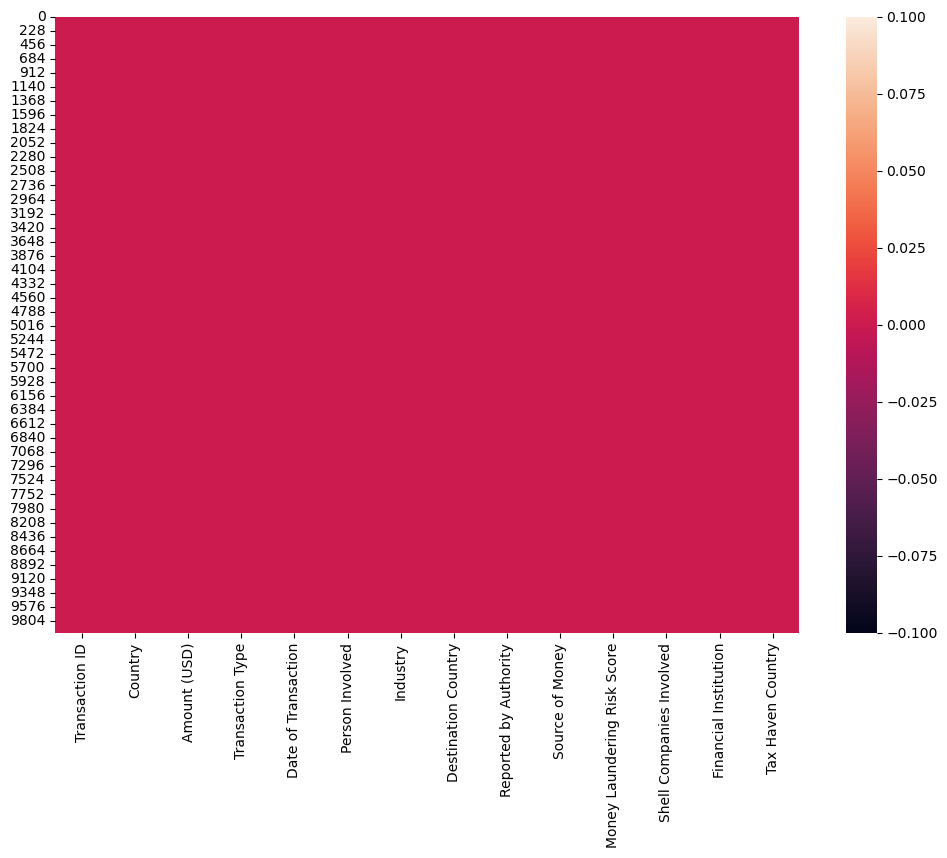

In [9]:
# Visualize with heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_BBMoney_Data.isnull())

It is obvious there are no more missing values in the dataset.

In [10]:
# Checking the unique values of objects-column
for col in df_BBMoney_Data.select_dtypes(include='object').columns:
    print(col)
    print(df_BBMoney_Data[col].unique())

Transaction ID
['TX0000000001' 'TX0000000002' 'TX0000000003' ... 'TX0000009998'
 'TX0000009999' 'TX0000010000']
Country
['Brazil' 'China' 'UK' 'UAE' 'South Africa' 'Russia' 'Switzerland' 'India'
 'USA' 'Singapore']
Transaction Type
['Offshore Transfer' 'Stocks Transfer' 'Cash Withdrawal' 'Cryptocurrency'
 'Property Purchase']
Date of Transaction
['2013-01-01 00:00:00' '2013-01-01 01:00:00' '2013-01-01 02:00:00' ...
 '2014-02-21 13:00:00' '2014-02-21 14:00:00' '2014-02-21 15:00:00']
Person Involved
['Person_1101' 'Person_7484' 'Person_3655' ... 'Person_6348' 'Person_4171'
 'Person_3267']
Industry
['Construction' 'Luxury Goods' 'Oil & Gas' 'Real Estate' 'Arms Trade'
 'Casinos' 'Finance']
Destination Country
['USA' 'South Africa' 'Switzerland' 'Russia' 'Brazil' 'UK' 'India' 'China'
 'Singapore' 'UAE']
Source of Money
['Illegal' 'Legal']
Financial Institution
['Bank_40' 'Bank_461' 'Bank_387' 'Bank_353' 'Bank_57' 'Bank_436'
 'Bank_452' 'Bank_88' 'Bank_87' 'Bank_404' 'Bank_273' 'Bank_252'
 '

In [11]:
# Finding number of unique values in the column
df_BBMoney_Data.nunique().to_frame("No.of unique values")

,No.of unique values
Transaction ID,10000
Country,10
Amount (USD),10000
Transaction Type,5
Date of Transaction,10000
Person Involved,6320
Industry,7
Destination Country,10
Reported by Authority,2
Source of Money,2


All the features have more than one single values.

In [12]:
# Checking the list of counts of target
df_BBMoney_Data["Reported by Authority"].unique()

array([ True, False])

There are two categories present in the target column namely "True" Or "False"

In [13]:
# Checking the unique values in target column
df_BBMoney_Data['Reported by Authority'].value_counts()

False    7995
True     2005
Name: Reported by Authority, dtype: int64

We can assume that "True" stands for Fraudulent(high risk) and "False" for Non-Fraudulent/Legitimate /(low risk).

### Data Description 

In [14]:
# Statistical summary of numerical columns
df_BBMoney_Data.describe()

,Amount (USD),Money Laundering Risk Score,Shell Companies Involved
count,1.000000e+04,10000.000000,10000.000000
mean,2.501818e+06,5.526400,4.469400
std,1.424364e+06,2.893603,2.879773
min,1.003180e+04,1.000000,0.000000
25%,1.279005e+06,3.000000,2.000000
50%,2.501310e+06,6.000000,4.000000
75%,3.722416e+06,8.000000,7.000000
max,4.999812e+06,10.000000,9.000000


These are the statistical details of the numerical columns.The dataset summary looks good and has no negative values.

From the above we can analyse further-:

* The counts of all the columns are of same values,meaning there are no missing values in the dataset.
* The mean value is slightly higher than the median(50%) in the **Amount** and **Shell Companies involved** columns, an indication that the data is skewed to right in these columns.
* The datas in the column **Money Laundering Risk Score** is less in mean value to the median,meaning that this data is skewed to the left.
* There are differences between 75% and max, which shows the presence of outliers in the dataset.
* We also notice the Standard deviation,min,25% percentile from this describe method.

In [15]:
# Lets also check the statistical distribution for numerical features
df_BBMoney_Data.describe().T

,count,mean,std,min,25%,50%,75%,max
Amount (USD),10000.0,2.501818e+06,1.424364e+06,10031.79673,1.279005e+06,2.501310e+06,3.722416e+06,4.999812e+06
Money Laundering Risk Score,10000.0,5.526400e+00,2.893603e+00,1.00000,3.000000e+00,6.000000e+00,8.000000e+00,1.000000e+01
Shell Companies Involved,10000.0,4.469400e+00,2.879773e+00,0.00000,2.000000e+00,4.000000e+00,7.000000e+00,9.000000e+00


### Exploratory Data Analysis (EDA)

**Univariate Analysis**

In [16]:
# The number Reports by the Authority 
print(df_BBMoney_Data['Reported by Authority'].value_counts())

False    7995
True     2005
Name: Reported by Authority, dtype: int64


In [17]:
# The % rate of Reports by the Authority
target_df=df_BBMoney_Data['Reported by Authority'].value_counts()*100/df_BBMoney_Data.shape[0]
target_df

False    79.95
True     20.05
Name: Reported by Authority, dtype: float64

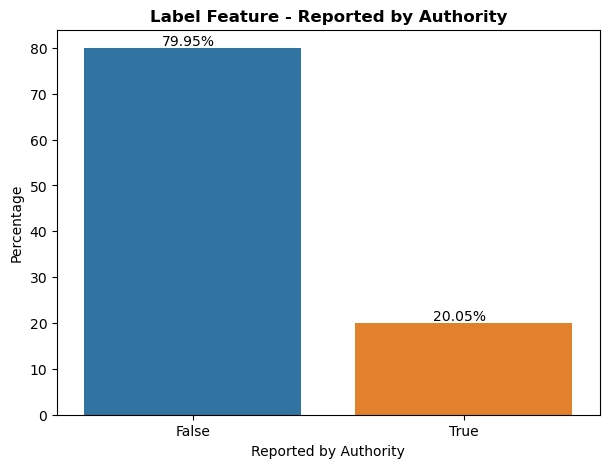

In [18]:
plt.figure(figsize=(7,5))
plt.title("Label Feature - Reported by Authority",fontdict={'fontweight':'bold','fontsize':12})
ax=sns.barplot(x=target_df.index,y=target_df.values)
plt.xlabel('Reported by Authority')
plt.ylabel('Percentage')

for p in ax.patches:
    height=p.get_height()
    width=p.get_width()
    x,_=p.get_xy()
    ax.text(x+width/2.8,height+0.5,f'{height:.2f}%')

The target distribution shows that **79.95%** of transactions were **not reported by authorities**, while **20.05%** were reported. This indicates a moderately imbalanced classification problem, with non-reported cases forming the clear majority.

In [19]:
# Lets Separate the numerical from categorical columns

# checking out the categorical columns
categorical_col = []
for i in df_BBMoney_Data.dtypes.index:
    if df_BBMoney_Data.dtypes[i] == "object":
        categorical_col.append(i)
print("categorical columns:", categorical_col)
print("\n")

# Checking for Numerical column
numerical_col = []
for i in df_BBMoney_Data.dtypes.index:
    if df_BBMoney_Data.dtypes[i]!= "object":
        numerical_col.append(i)
print("numerical columns:", numerical_col)

categorical columns: ['Transaction ID', 'Country', 'Transaction Type', 'Date of Transaction', 'Person Involved', 'Industry', 'Destination Country', 'Source of Money', 'Financial Institution', 'Tax Haven Country']


numerical columns: ['Amount (USD)', 'Reported by Authority', 'Money Laundering Risk Score', 'Shell Companies Involved']


**Count Plots**

False    7995
True     2005
Name: Reported by Authority, dtype: int64


(array([0, 1]), [Text(0, 0, 'False'), Text(1, 0, 'True')])

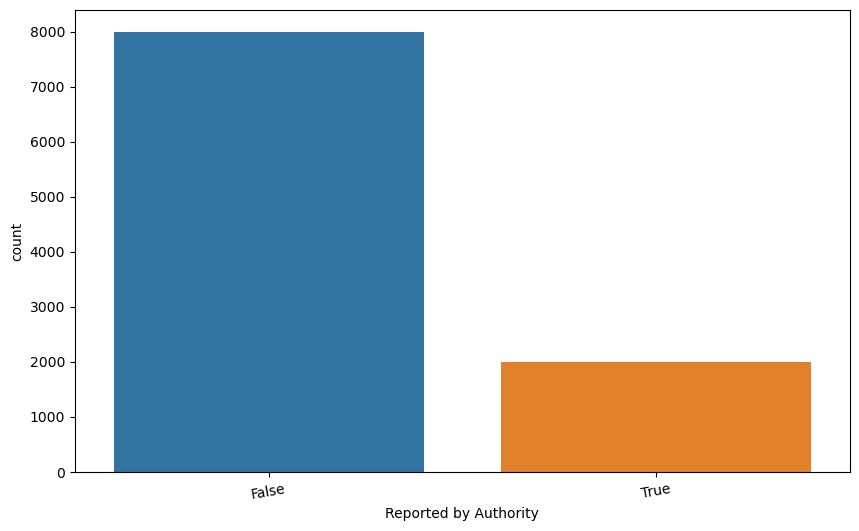

In [20]:
# Visualizing the count of Reported by Authority
plt.figure(figsize=(10,6))
sns.countplot(df_BBMoney_Data['Reported by Authority'],order=df_BBMoney_Data['Reported by Authority'].value_counts().index)
print(df_BBMoney_Data['Reported by Authority'].value_counts())
plt.xticks(rotation=10)

The count plot confirms that the dataset contains **about 8,000 transactions labeled False** and **about 2,000 labeled True** under **Reported by Authority**. This reinforces that the target variable is imbalanced, with non-reported transactions making up the majority of cases.


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, '9'),
  Text(1, 0, '3'),
  Text(2, 0, '1'),
  Text(3, 0, '10'),
  Text(4, 0, '4'),
  Text(5, 0, '6'),
  Text(6, 0, '8'),
  Text(7, 0, '7'),
  Text(8, 0, '5'),
  Text(9, 0, '2')])

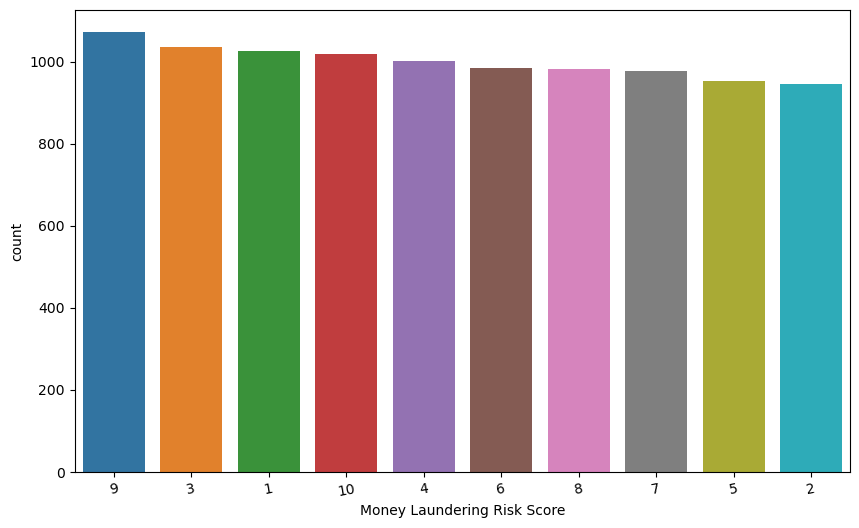

In [21]:
# Visualizing the count of Money Laundering Risk Score
plt.figure(figsize=(10,6))
sns.countplot(df_BBMoney_Data['Money Laundering Risk Score'],order=df_BBMoney_Data['Money Laundering Risk Score'].value_counts().index)
plt.xticks(rotation=10)

This chart shows that the **Money Laundering Risk Score** is distributed fairly evenly across all score levels, with each category having **roughly 950 to 1,080 records**. Score **9** has the highest count at just over **1,070**, while score **2** has the lowest at just under **950**. This suggests that the feature is well spread across the scoring range, with no single risk score dominating the dataset.


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, '0'),
  Text(1, 0, '5'),
  Text(2, 0, '2'),
  Text(3, 0, '6'),
  Text(4, 0, '4'),
  Text(5, 0, '1'),
  Text(6, 0, '9'),
  Text(7, 0, '8'),
  Text(8, 0, '7'),
  Text(9, 0, '3')])

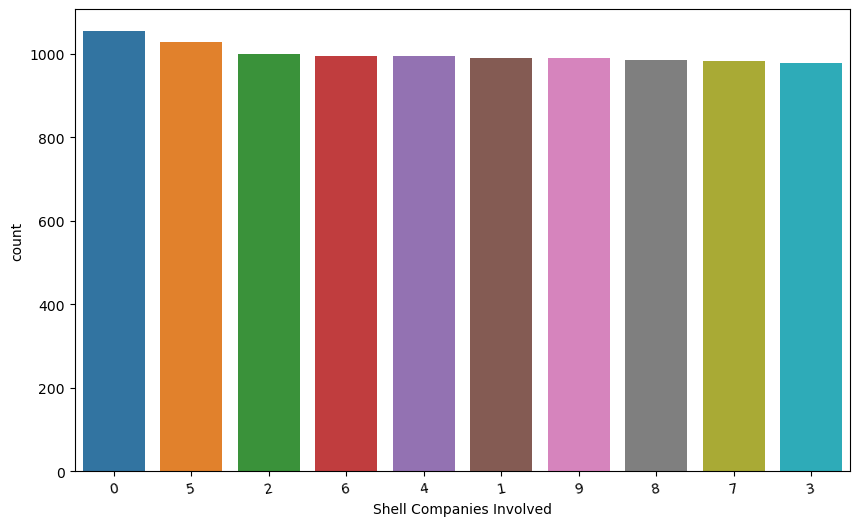

In [22]:
# Visualizing the count of Shell Companies Involved
plt.figure(figsize=(10,6))
sns.countplot(df_BBMoney_Data['Shell Companies Involved'],order=df_BBMoney_Data['Shell Companies Involved'].value_counts().index)
plt.xticks(rotation=10)

This chart shows that **Shell Companies Involved** is distributed very evenly across all categories, with each value having **about 980 to 1,060 records**. The category **0** has the highest count at just over **1,050**, while **3** has the lowest at just under **980**. This suggests that the feature is well balanced across the different counts of shell companies involved, with no single category dominating the dataset.


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'China'),
  Text(1, 0, 'South Africa'),
  Text(2, 0, 'UK'),
  Text(3, 0, 'Brazil'),
  Text(4, 0, 'Russia'),
  Text(5, 0, 'Singapore'),
  Text(6, 0, 'India'),
  Text(7, 0, 'Switzerland'),
  Text(8, 0, 'UAE'),
  Text(9, 0, 'USA')])

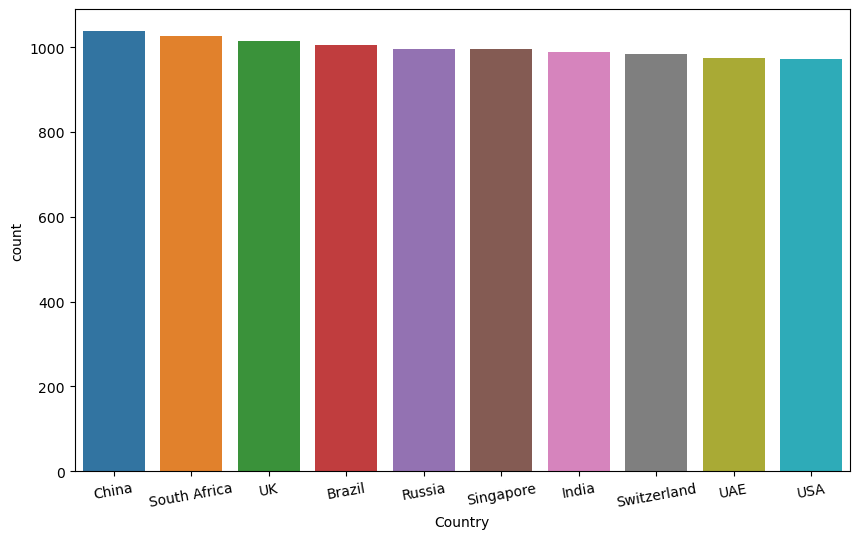

In [23]:
# Visualizing the count of Country
plt.figure(figsize=(10,6))
sns.countplot(df_BBMoney_Data['Country'],order=df_BBMoney_Data['Country'].value_counts().index)
plt.xticks(rotation=10)

This chart shows that transactions are **fairly evenly distributed across all countries**, with each country contributing **roughly 970 to 1,040 records**. **China** has the highest count, while the **USA** has the lowest, but the differences are not so significant. This suggests that the **Country** feature is balanced across categories and does not appear to be dominated by any single country.


(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Property Purchase'),
  Text(1, 0, 'Stocks Transfer'),
  Text(2, 0, 'Offshore Transfer'),
  Text(3, 0, 'Cash Withdrawal'),
  Text(4, 0, 'Cryptocurrency')])

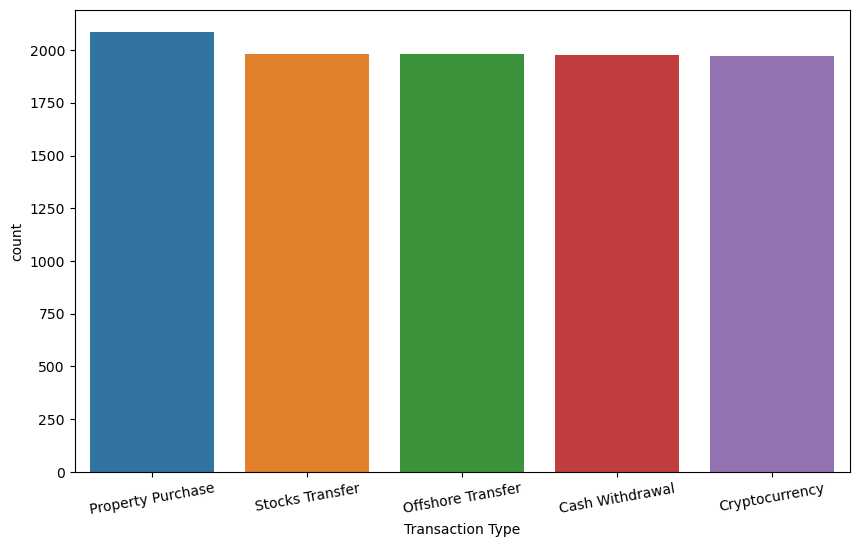

In [24]:
# Visualizing the count of Transaction Type
plt.figure(figsize=(10,6))
sns.countplot(df_BBMoney_Data['Transaction Type'],order=df_BBMoney_Data['Transaction Type'].value_counts().index)
plt.xticks(rotation=10)

This chart shows that **transaction types are fairly evenly distributed**, with each category contributing close to **2,000 records**. **Property Purchase** has the highest count at a little over **2,100**, while **Stocks Transfer**, **Offshore Transfer**, **Cash Withdrawal**, and **Cryptocurrency** each appear at slightly lower but very similar levels. This suggests that the **Transaction Type** feature is well balanced across categories, with no single transaction type dominating the dataset.


(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'Finance'),
  Text(1, 0, 'Construction'),
  Text(2, 0, 'Luxury Goods'),
  Text(3, 0, 'Real Estate'),
  Text(4, 0, 'Arms Trade'),
  Text(5, 0, 'Casinos'),
  Text(6, 0, 'Oil & Gas')])

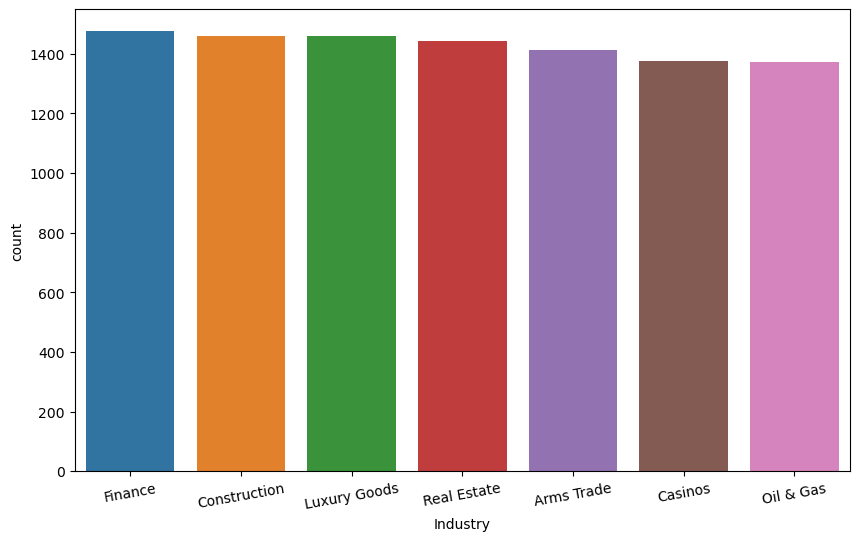

In [25]:
# Visualizing the count of Industry
plt.figure(figsize=(10,6))
sns.countplot(df_BBMoney_Data['Industry'],order=df_BBMoney_Data['Industry'].value_counts().index)
plt.xticks(rotation=10)

This chart shows that **industry categories are fairly evenly distributed**, with each industry contributing roughly **1,370 to 1,480 records**. **Finance** has the highest count, while **Oil & Gas** and **Casinos** have the lowest, though the differences are relatively small. This suggests that the **Industry** feature is well balanced across categories and is not dominated by any single industry.


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'USA'),
  Text(1, 0, 'Russia'),
  Text(2, 0, 'India'),
  Text(3, 0, 'Singapore'),
  Text(4, 0, 'South Africa'),
  Text(5, 0, 'Switzerland'),
  Text(6, 0, 'China'),
  Text(7, 0, 'UK'),
  Text(8, 0, 'UAE'),
  Text(9, 0, 'Brazil')])

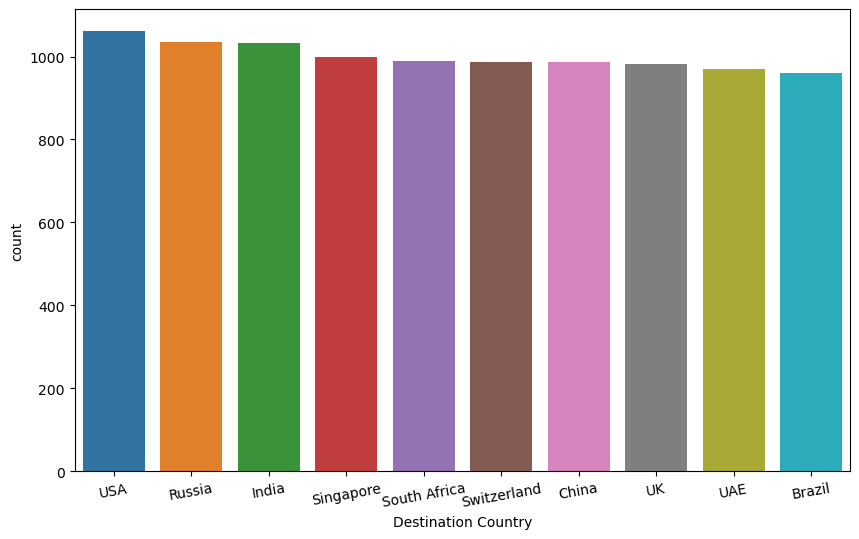

In [26]:
# Visualizing the count of Destination Country
plt.figure(figsize=(10,6))
sns.countplot(df_BBMoney_Data['Destination Country'],order=df_BBMoney_Data['Destination Country'].value_counts().index)
plt.xticks(rotation=10)

The above chart shows that **Destination Country** is fairly evenly distributed, with each country contributing **about 960 to 1,070 records**. The **USA** has the highest count, while **Brazil** has the lowest, but the differences across countries are relatively small. This suggests that the **Destination Country** feature is well balanced and not dominated by any single destination.


(array([0, 1]), [Text(0, 0, 'Illegal'), Text(1, 0, 'Legal')])

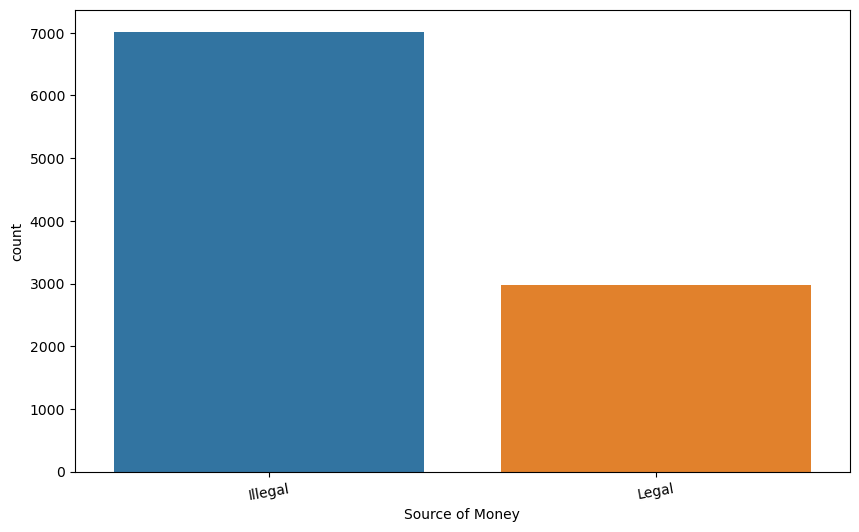

In [27]:
# Visualizing the count of Source of Money
plt.figure(figsize=(10,6))
sns.countplot(df_BBMoney_Data['Source of Money'],order=df_BBMoney_Data['Source of Money'].value_counts().index)
plt.xticks(rotation=10)

The chart shows that **Source of Money** is clearly imbalanced, with **illegal sources making up about 7,000 transactions** compared with **about 3,000 transactions from legal sources**. This suggests that the dataset is dominated by suspicious or unlawful funding sources, which would have a strong influence on the fraud detection patterns.

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'Panama'),
  Text(1, 0, 'Luxembourg'),
  Text(2, 0, 'Cayman Islands'),
  Text(3, 0, 'Singapore'),
  Text(4, 0, 'Bahamas'),
  Text(5, 0, 'Switzerland')])

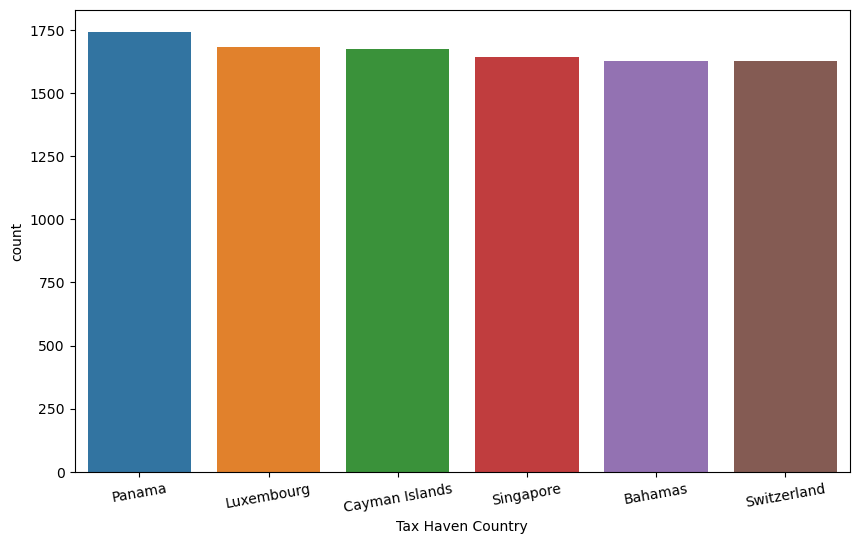

In [28]:
# Visualizing the count of Financial Institution
plt.figure(figsize=(10,6))
sns.countplot(df_BBMoney_Data['Tax Haven Country'],order=df_BBMoney_Data['Tax Haven Country'].value_counts().index)
plt.xticks(rotation=10)

The distribution of **Tax Haven Country** tells a fairly balanced tales. Transactions are spread across major tax haven jurisdictions, with **Panama** appearing most often, followed closely by **Luxembourg, the Cayman Islands, Singapore, the Bahamas, and Switzerland**. Although Panama records the highest number of transactions, the differences across countries are relatively small. This suggests that suspicious or **high-risk financial activity** is not concentrated in just one offshore location, but is instead distributed across several well-known tax haven jurisdictions. In practical terms, the dataset reflects a broad international pattern of offshore financial movement rather than dependence on a single destination.


**Checking The Skewness**

In [29]:
# Lets have a look at the skewness
df_BBMoney_Data.skew()

Amount (USD)                   0.011124
Reported by Authority          1.496324
Money Laundering Risk Score   -0.011003
Shell Companies Involved       0.005806
dtype: float64

The dataset is slightly skewed to the left, no need to remove it.

**Visualizing the data distribution in the columns after checking skewness**.

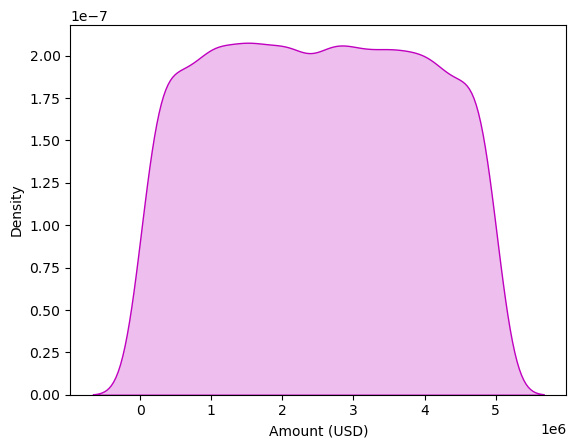

In [30]:
# Data distribution in Amount (USD) after skewness
sns.distplot(df_BBMoney_Data['Amount (USD)'], color = "m", kde_kws = {"shade":True}, hist = False)
plt.show()

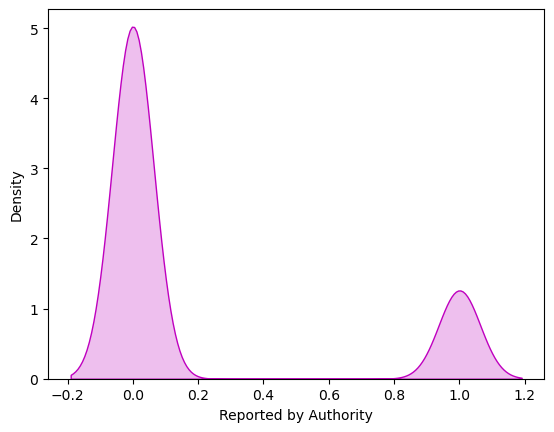

In [31]:
# Data distribution in Reported by Authority after skewness
sns.distplot(df_BBMoney_Data['Reported by Authority'], color = "m", kde_kws = {"shade":True}, hist = False)
plt.show()

This density plot shows that **Reported by Authority** is a **binary variable** with values concentrated at **0** and **1**. The higher peak near **0** indicates that a larger share of transactions were **not reported by authorities**, while the smaller peak near **1** shows that fewer transactions were reported.


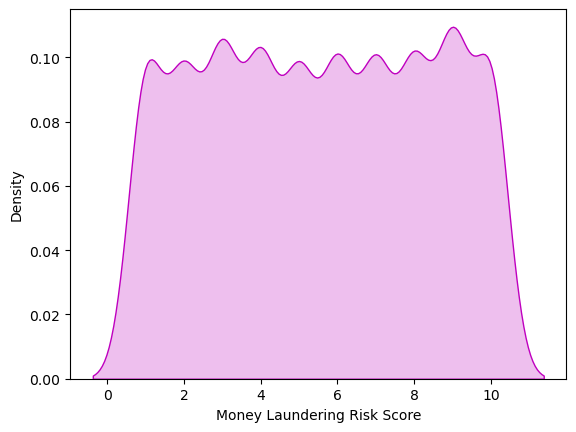

In [32]:
# Data distribution in Money Laundering Risk Score after skewness
sns.distplot(df_BBMoney_Data['Money Laundering Risk Score'], color = "m", kde_kws = {"shade":True}, hist = False)
plt.show()

This density plot shows that the **Money Laundering Risk Score** is distributed fairly evenly across its range, with no single score dominating the dataset. The shape is relatively flat with small fluctuations, suggesting that transactions are spread across low, medium, and high risk levels in a fairly balanced way. This indicates that the feature provides variation across the full scoring scale, which would be useful for distinguishing different levels of transaction risk.


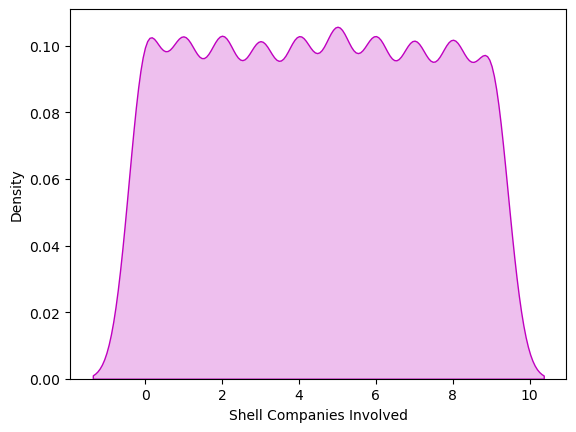

In [33]:
# Data distribution in Shell Companies Involved after skewness
sns.distplot(df_BBMoney_Data['Shell Companies Involved'], color = "m", kde_kws = {"shade":True}, hist = False)
plt.show()

The density plot indicates that **Shell Companies Involved** is distributed fairly evenly across its range, with no single value occurring much more often than the others. The shape is relatively flat with only small fluctuations, suggesting that transactions involve varying numbers of shell companies at broadly similar frequencies. This means the feature has good spread and may be useful for capturing differences in transaction complexity or concealment risk.


**Bivariate analysis**

Checking the relationships between the target and feature variables

<AxesSubplot:title={'center':'Country in relation with Target(Reported by Authority)'}, xlabel='Country', ylabel='Reported by Authority'>

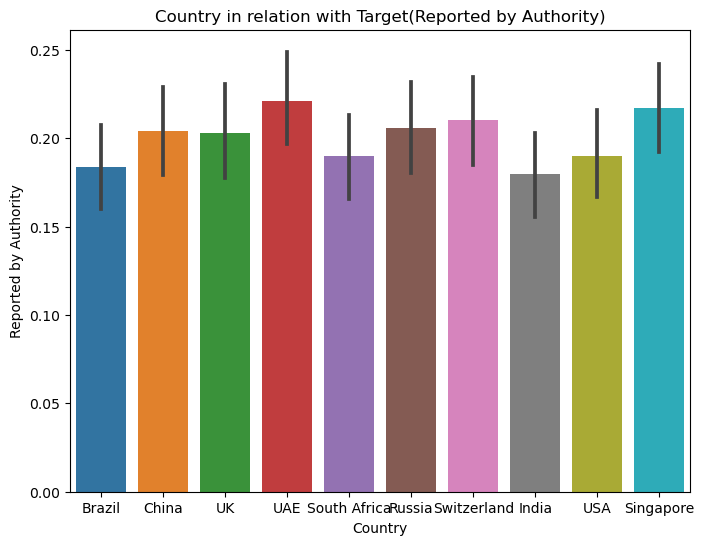

In [34]:
# barplot for Country in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("Country in relation with Target(Reported by Authority)")
sns.barplot(x = 'Country', y = 'Reported by Authority', data = df_BBMoney_Data)

The reporting rate is fairly similar across countries, indicating that suspicious transactions are distributed internationally rather than concentrated in one location. However, **UAE** and **Singapore** show slightly higher reporting levels, while **India** and **Brazil** record the lowest.


<AxesSubplot:title={'center':'Transaction Type in relation with Target(Reported by Authority)'}, xlabel='Transaction Type', ylabel='Reported by Authority'>

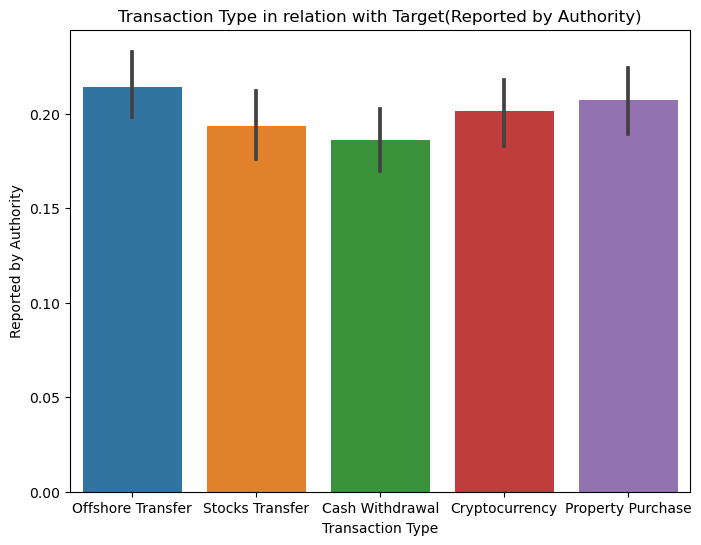

In [35]:
# barplot for Transaction Type in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("Transaction Type in relation with Target(Reported by Authority)")
sns.barplot(x = 'Transaction Type', y = 'Reported by Authority', data = df_BBMoney_Data)

Reporting by the authority is spread across different forms of transactions rather than concentrated in one category. **Offshore Transfer** has the highest reporting rate at **about 21.5%**, followed by **Property Purchase** at **about 20.7%** and **Cryptocurrency** at **about 20.1%**. **Stocks Transfer** is around **19.4%**, while **Cash Withdrawal** records the lowest rate at **about 18.6%**.


<AxesSubplot:title={'center':'Industry in relation with Target(Reported by Authority)'}, xlabel='Industry', ylabel='Reported by Authority'>

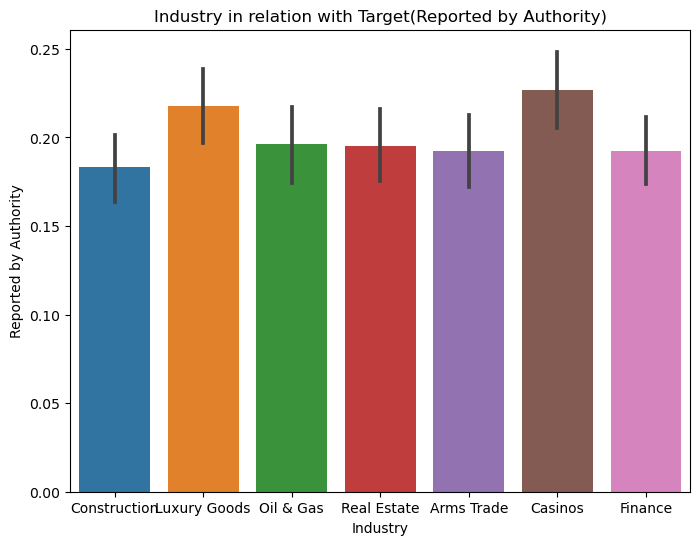

In [36]:
# barplot for Industry in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("Industry in relation with Target(Reported by Authority)")
sns.barplot(x = 'Industry', y = 'Reported by Authority', data = df_BBMoney_Data)

As shown above, **Casinos** has the highest reporting rate at **about 22.5%**, followed by **Luxury Goods** at **about 21.8%**. **Oil & Gas**, **Real Estate**, **Arms Trade**, and **Finance** fall in the middle at roughly **19% to 20%**, while **Construction** records the lowest rate at **about 18.4%**.


<AxesSubplot:title={'center':'Destination Country in relation with Target(Reported by Authority)'}, xlabel='Destination Country', ylabel='Reported by Authority'>

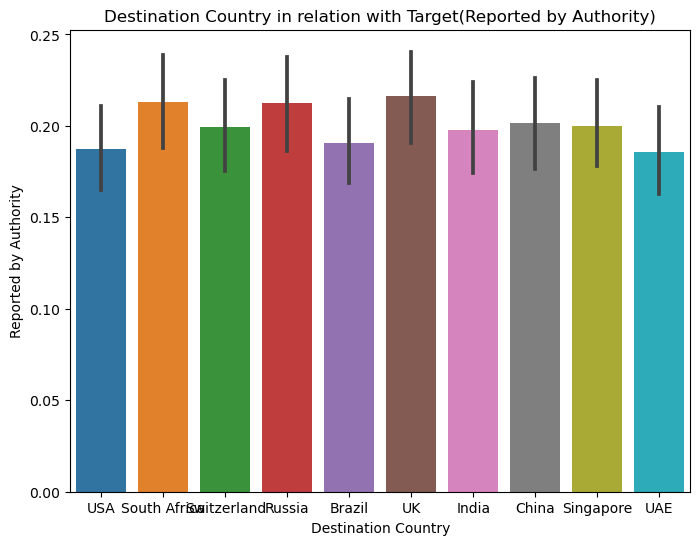

In [37]:
# barplot for Destination Country in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("Destination Country in relation with Target(Reported by Authority)")
sns.barplot(x = 'Destination Country', y = 'Reported by Authority', data = df_BBMoney_Data)

The **UK** has the highest reporting rate at **about 21.6%**, followed by **South Africa** and **Russia** at **about 21.3%** each. **China**, **Switzerland**, and **Singapore** are around **20.0% to 20.2%**, while **Brazil** and the **USA** are lower at **about 19.0% and 18.8%**, and the **UAE** records the lowest rate at **about 18.5%**.


<AxesSubplot:title={'center':'Source of Money in relation with Target(Reported by Authority)'}, xlabel='Source of Money', ylabel='Reported by Authority'>

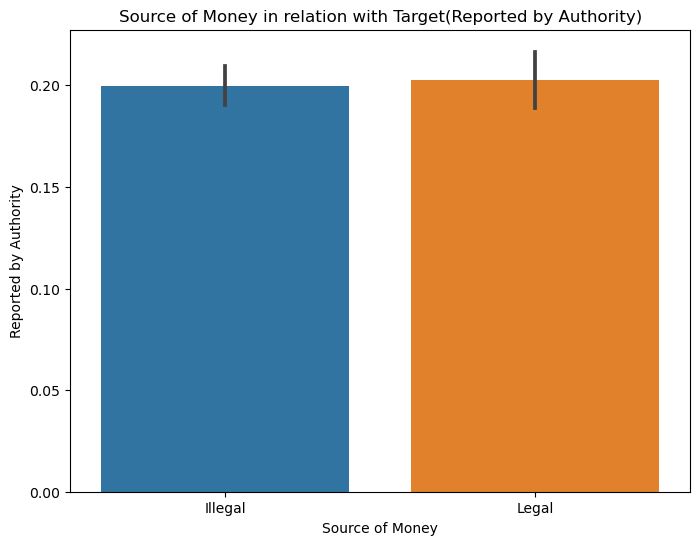

In [38]:
# barplot for Source of Money in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("Source of Money in relation with Target(Reported by Authority)")
sns.barplot(x = 'Source of Money', y = 'Reported by Authority', data = df_BBMoney_Data)

The above shows source of legal money reported by the authority at about **20.2%** and illegal sources at about **20.0%**. 

<AxesSubplot:title={'center':'Tax Haven Country in relation with Target(Reported by Authority)'}, xlabel='Tax Haven Country', ylabel='Reported by Authority'>

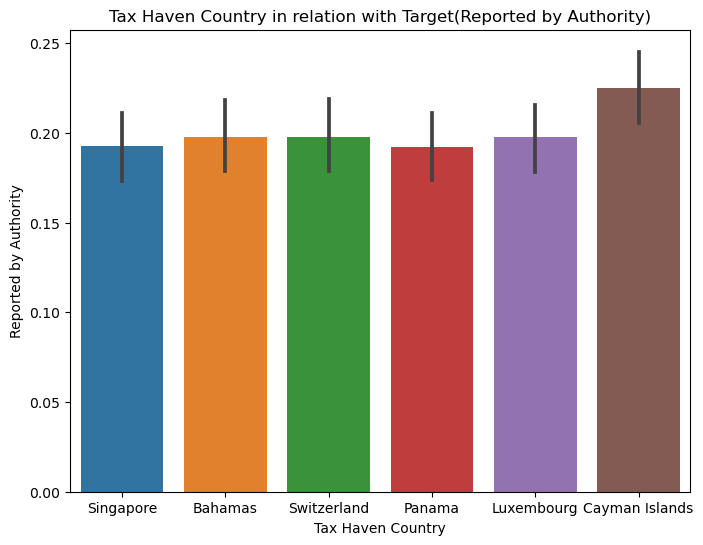

In [39]:
# barplot for Tax Haven Country in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("Tax Haven Country in relation with Target(Reported by Authority)")
sns.barplot(x = 'Tax Haven Country', y = 'Reported by Authority', data = df_BBMoney_Data)

Reports by the authority are fairly close across countries that are tax haven an indication that the reporting is spread across multiple offshore jurisdictions rather than concentrated in one. The **Cayman Islands** has the highest reporting rate at **about 22.4%**, while **Panama** and **Singapore** have the lowest at **about 19.2% to 19.3%**. **Bahamas, Switzerland, and Luxembourg** fall in between at roughly **19.8%**.


<AxesSubplot:title={'center':'Money Laundering Risk Score in relation with Target(Reported by Authority)'}, xlabel='Money Laundering Risk Score', ylabel='Reported by Authority'>

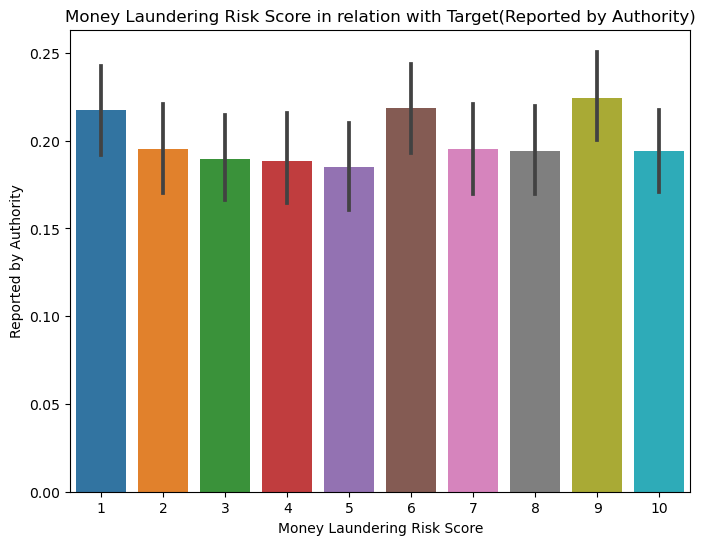

In [40]:
# barplot for Money Laundering Risk Score in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("Money Laundering Risk Score in relation with Target(Reported by Authority)")
sns.barplot(x = 'Money Laundering Risk Score', y = 'Reported by Authority', data = df_BBMoney_Data)

As show above,the **Money Laundering Risk Score** as Reported by the authority are fairly similar across  categories, suggesting that the report does not change sharply with score level alone. The highest reporting rates appear at **score 9 (about 22.4%)** and **score 6 (about 21.9%)**, while the lowest is at **score 5 (about 18.5%)**. Most other score levels fall within a narrow range of roughly **19% to 22%**.


<AxesSubplot:title={'center':'Shell Companies Involved in relation with Target(Reported by Authority)'}, xlabel='Shell Companies Involved', ylabel='Reported by Authority'>

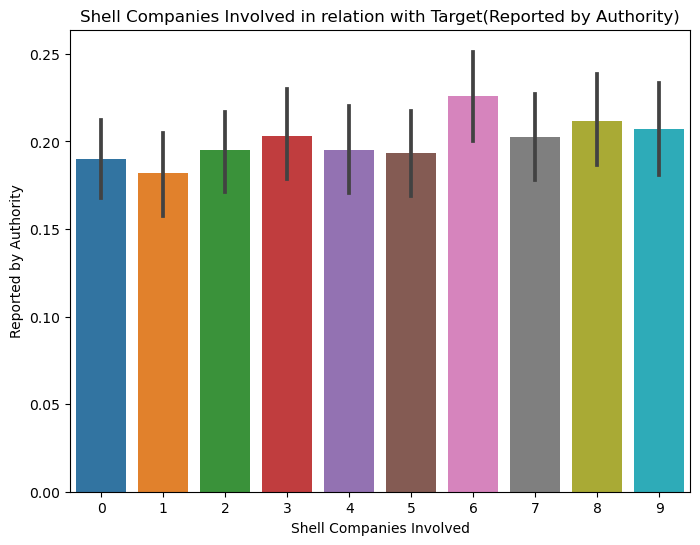

In [41]:
# barplot for Shell Companies Involved in relation to the target
fig = plt.figure(figsize = (8,6))
plt.title("Shell Companies Involved in relation with Target(Reported by Authority)")
sns.barplot(x = 'Shell Companies Involved', y = 'Reported by Authority', data = df_BBMoney_Data)

Reporting rates vary only slightly with the number of **shell companies involved**, indicating no sharp linear pattern. The highest reporting rate is observed when **6 shell companies** are involved at **about 22.6%**, while the lowest occurs at **1 shell company** with **about 18.2%**. Most other categories fall within a narrow range of roughly **19% to 21%**.


In [42]:
# Normalize column names to a consistent format
df_BBMoney_Data.columns = (
    df_BBMoney_Data.columns
      .str.strip()
      .str.replace(' ', '_')
      .str.replace(r'[()]', '', regex=True)
      .str.replace('/', '_')
)

# Target column (normalized)
target_col = 'Reported_by_Authority'   # adjust if your normalized name differs

# Categorical features to compare (normalized names)
categorical_features = [
    'Transaction_ID', 'Country', 'Transaction_Type', 'Date_of_Transaction',
    'Person_Involved', 'Industry', 'Destination_Country', 'Source_of_Money',
    'Financial_Institution', 'Tax_Haven_Country'
]

# Parameters
max_unique = 30     # skip features with more than this unique values (or use top_n)
top_n = 10          # if feature has many categories, plot only top_n by count

In [43]:
# Checking target presence
if target_col not in df_BBMoney_Data.columns:
    raise KeyError(f"Target column '{target_col}' not found. Available columns: {df_BBMoney_Data.columns.tolist()}")

# We Ensure target is numeric 0/1
df_BBMoney_Data[target_col] = df_BBMoney_Data[target_col].astype(int)

# Verifying and filter features that exist
existing = [c for c in categorical_features if c in df_BBMoney_Data.columns]
missing = [c for c in categorical_features if c not in df_BBMoney_Data.columns]
print("Using features:", existing)
if missing:
    print("Missing (skipped):", missing)

Using features: ['Transaction_ID', 'Country', 'Transaction_Type', 'Date_of_Transaction', 'Person_Involved', 'Industry', 'Destination_Country', 'Source_of_Money', 'Financial_Institution', 'Tax_Haven_Country']


In [44]:
# Function to plot proportion reported by category
def plot_report_rate(data, cat_col, target, top_n=10):
    # compute counts and rates
    counts = data[cat_col].value_counts(dropna=False)
    if counts.size == 0:
        print(f"Skipping {cat_col}: no values")
        return

    # choosing the categories to show
    if counts.size > max_unique:
        cats = counts.nlargest(top_n).index
        subset = data[data[cat_col].isin(cats)]
        title_extra = f"(top {top_n} of {counts.size} categories shown)"
    else:
        subset = data
        title_extra = ""

    agg = subset.groupby(cat_col)[target].agg(['mean','count']).rename(columns={'mean':'report_rate','count':'n'})
    agg = agg.sort_values('report_rate', ascending=False)

    plt.figure(figsize=(10,5))
    sns.barplot(x=agg.index.astype(str), y=agg['report_rate'])
    plt.ylabel('Proportion Reported (mean of target)')
    plt.xlabel(cat_col)
    plt.title(f'Proportion Reported by {cat_col} {title_extra}')
    plt.xticks(rotation=45, ha='right')

    # annotate counts under bars
    for i, (_, row) in enumerate(agg.iterrows()):
        plt.text(i, row['report_rate'] + 0.01, f"n={int(row['n'])}", ha='center', va='bottom', fontsize=9)

    plt.ylim(0, min(1.0, agg['report_rate'].max() + 0.12))
    plt.tight_layout()
    plt.show()

Skipping Transaction_ID: very high cardinality (10000 unique). Consider aggregating.


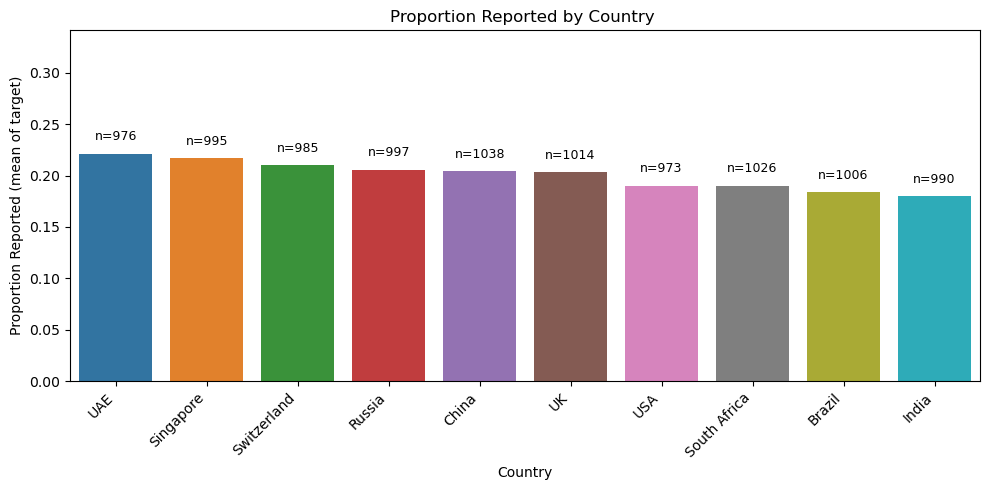

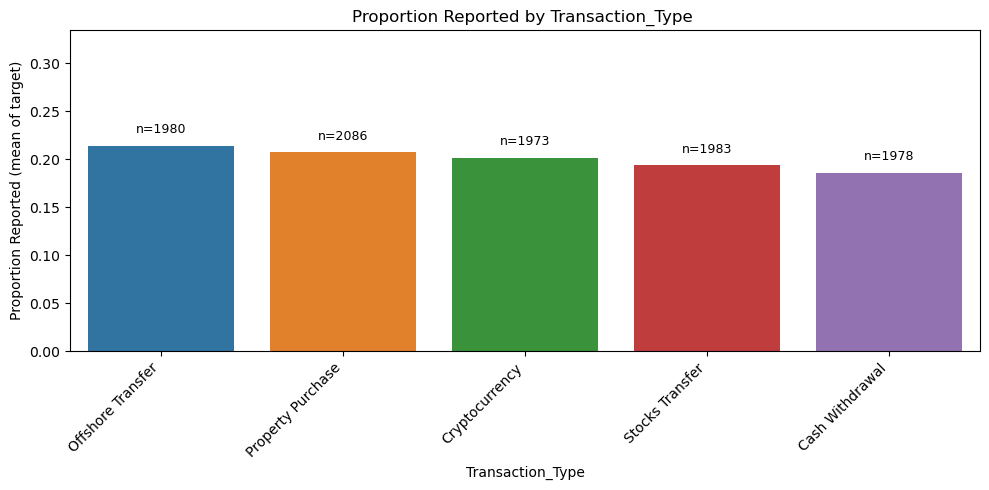

Skipping Date_of_Transaction: very high cardinality (10000 unique). Consider aggregating.
Skipping Person_Involved: very high cardinality (6320 unique). Consider aggregating.


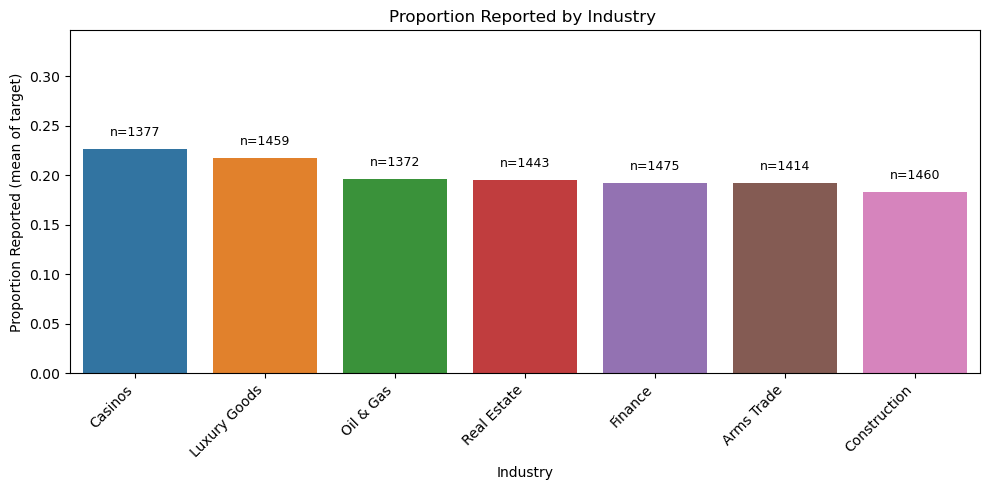

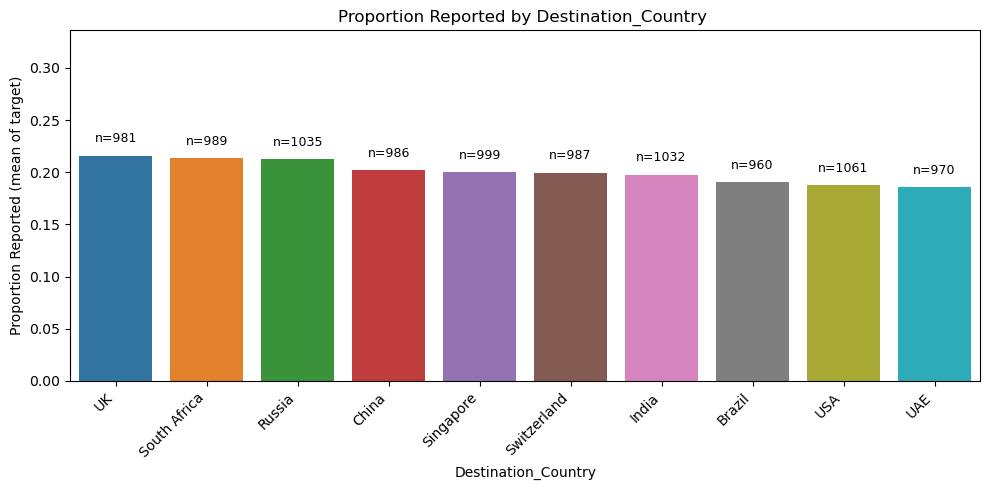

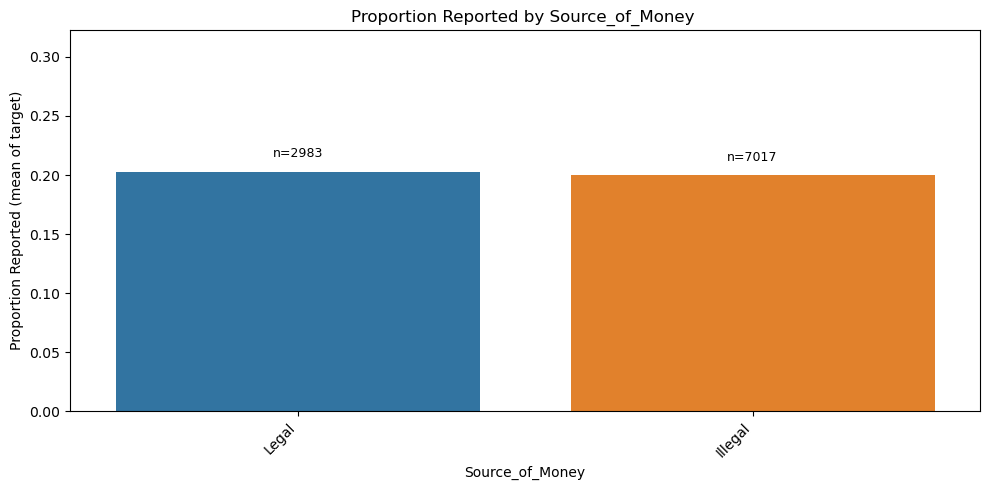

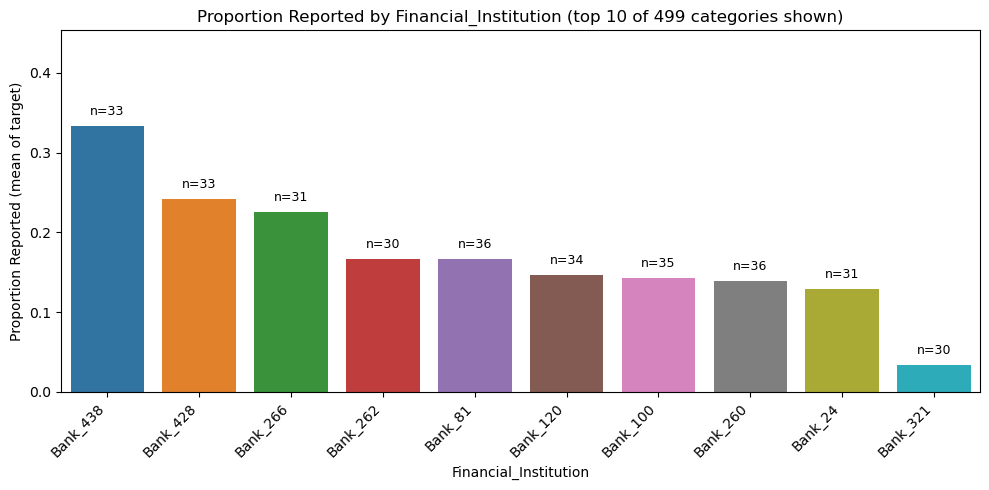

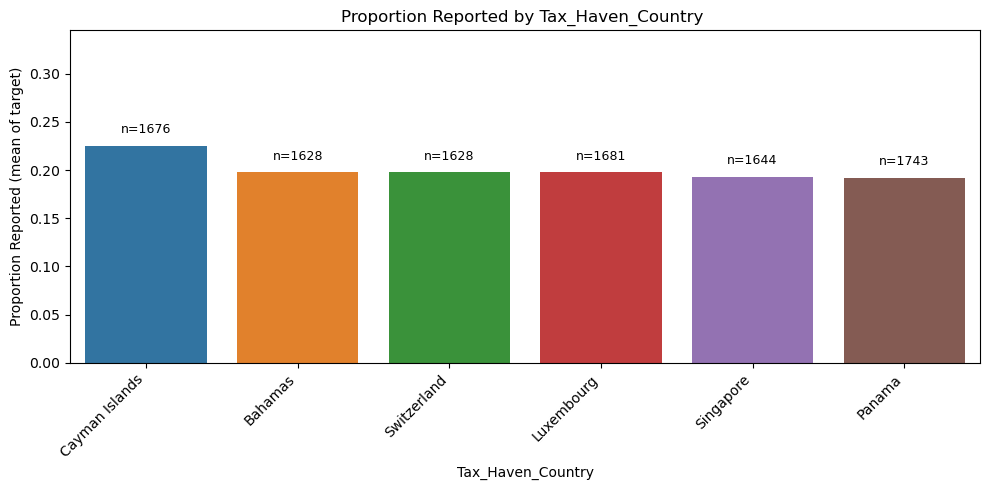

In [45]:
# Loop through features
for col in existing:
    # skip obvious ID or date columns if too many unique values
    unique_count = df_BBMoney_Data[col].nunique(dropna=False)
    if unique_count <= 1:
        print(f"Skipping {col}: single unique value.")
        continue
    if unique_count > 1000:
        print(f"Skipping {col}: very high cardinality ({unique_count} unique). Consider aggregating.")
        continue

    plot_report_rate(df_BBMoney_Data, col, target_col, top_n=top_n)

As show in the various charts above:

**Observation 1:**
Proportions reported by **country** are fairly close, mostly between **18% and 22%**. **UAE** has the highest proportion at about **22.1%**, while **India** has the lowest at about **18.0%**.

**Observation 2:**
Across **transaction types**, the differences are small. **Offshore Transfer** shows the highest reporting proportion at about **21.4%**, while **Cash Withdrawal** has the lowest at about **18.6%**.

**Observation 3:**
For **industry**, proportions reported remain relatively stable, but **Casinos** stands out with the highest rate at about **22.6%**. **Construction** is the lowest at about **18.4%**.

**Observation 4:**
By **destination country**, the spread is again modest. The **UK** has the highest reported cases at about **21.6%**, while the **UAE** has the lowest at about **18.5%**.

**Observation 5:**
For **source of money**, the proportions reported are almost identical. **Legal** sources are about **20.2%**, while **Illegal** sources are about **20.0%**, suggesting little separation from this feature alone.

**Observation 6:**
Among the top **financial institutions** shown, the proportions reported vary more widely than in most other categories. **Bank_438** has the highest proportion at about **33.3%**, while **Bank_321** has the lowest at about **3.3%**.

**Observation 7:**
Across **tax haven countries**, proportions reported are fairly similar, mostly around **19% to 22%**. The **Cayman Islands** records the highest proportion at about **22.5%**, while **Singapore** and **Panama** are the lowest at about **19.2%**.


**Multivariate**

**Faceted bar chart** (comparing reported rate across categories, faceted by a second categorical variable.)

In [46]:
# Lets use a copy with cleaned column names
df = df_BBMoney_Data.copy()
df_BBMoney_Data.columns = df_BBMoney_Data.columns.str.strip().str.replace(' ', '_').str.replace(r'[()]', '', regex=True)

In [47]:
# choosing variables
cat_x = 'Country'            # x-axis category (may want to limit to top N)
facet_col = 'Transaction_Type'  # facet by this variable
target = 'Reported_by_Authority'

# limit to top N categories for readability
top_n = 8
top_cats = df_BBMoney_Data[cat_x].value_counts().nlargest(top_n).index
plot_df = df_BBMoney_Data[df[cat_x].isin(top_cats) & df_BBMoney_Data[facet_col].notna()]

In [48]:
plot_df[target] = df_BBMoney_Data[target].astype(int)
agg = plot_df.groupby([cat_x, facet_col])[target].mean().reset_index(name='report_rate')

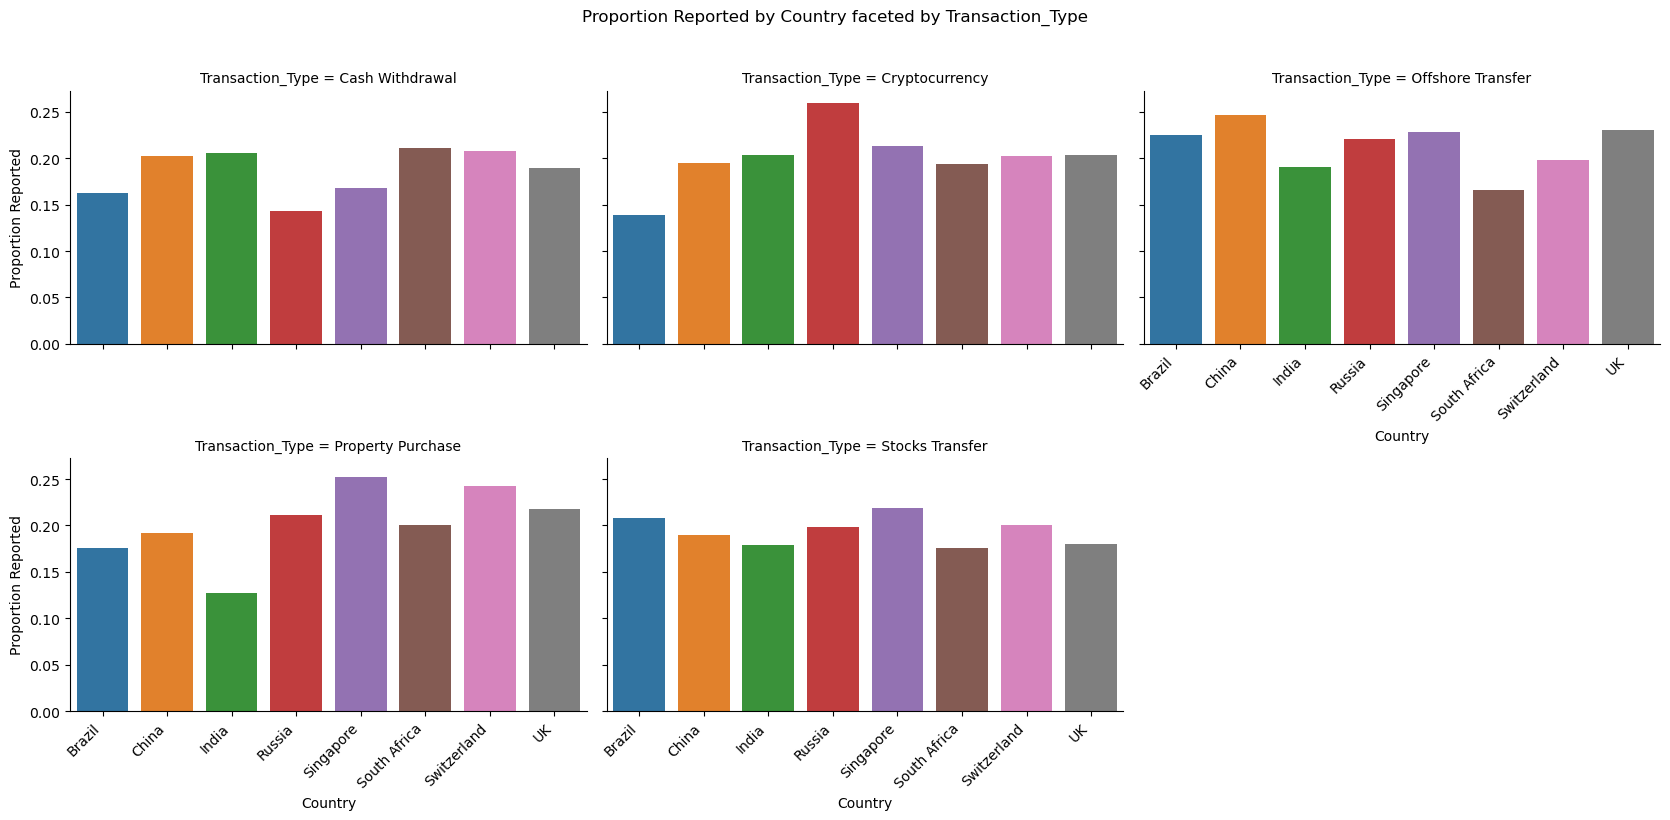

In [49]:
# faceted bar plot
g = sns.catplot(
    data=agg,
    x=cat_x, y='report_rate',
    col=facet_col,
    col_wrap=3,
    kind='bar',
    sharey=True,
    height=4, aspect=1.4
)

g.set_xticklabels(rotation=45, ha='right')
g.set_axis_labels(cat_x, 'Proportion Reported')
g.fig.suptitle(f'Proportion Reported by {cat_x} faceted by {facet_col}', y=1.02)
plt.tight_layout()
plt.show()

The relationship between **country** and the proportion of cases reported becomes more distinct when broken down by **transaction type**. For **Cryptocurrency**, **Russia** shows the highest reporting proportion at about **26%**, while **Brazil** is the lowest at about **14%**. For **Offshore Transfer**, **China** records the highest reporting rate at about **24.5%**, while **South Africa** is the lowest at about **16.7%**. In **Property Purchase**, **Singapore** and **Switzerland** stand out with reporting rates above **24%**, whereas **India** is much lower at about **12.8%**. For **Stocks Transfer**, the variation is smaller, with **Singapore** highest at about **22%** and **South Africa** lowest at about **17.6%**. Therefore, this suggests that reporting patterns depend not just on country alone, but on the combination of **country and transaction type**.


**Grouped (hue) stacked/side-by-side bar for two different categories**

In [50]:
# Lets choose variables
cat_x = 'Country'
cat_hue = 'Industry'
target = 'Reported_by_Authority'

In [51]:
# We then limit to top categories to keep plot readable
top_n_x = 10   # top countries
top_n_hue = 6  # top industries shown; others grouped as 'Other'
top_x = df_BBMoney_Data[cat_x].value_counts().nlargest(top_n_x).index
top_h = df_BBMoney_Data[cat_hue].value_counts().nlargest(top_n_hue).index

df_plot = df_BBMoney_Data[df_BBMoney_Data[cat_x].isin(top_x)].copy()
df_plot[cat_hue] = df_BBMoney_Data[cat_hue].where(df_BBMoney_Data[cat_hue].isin(top_h), other='Other')

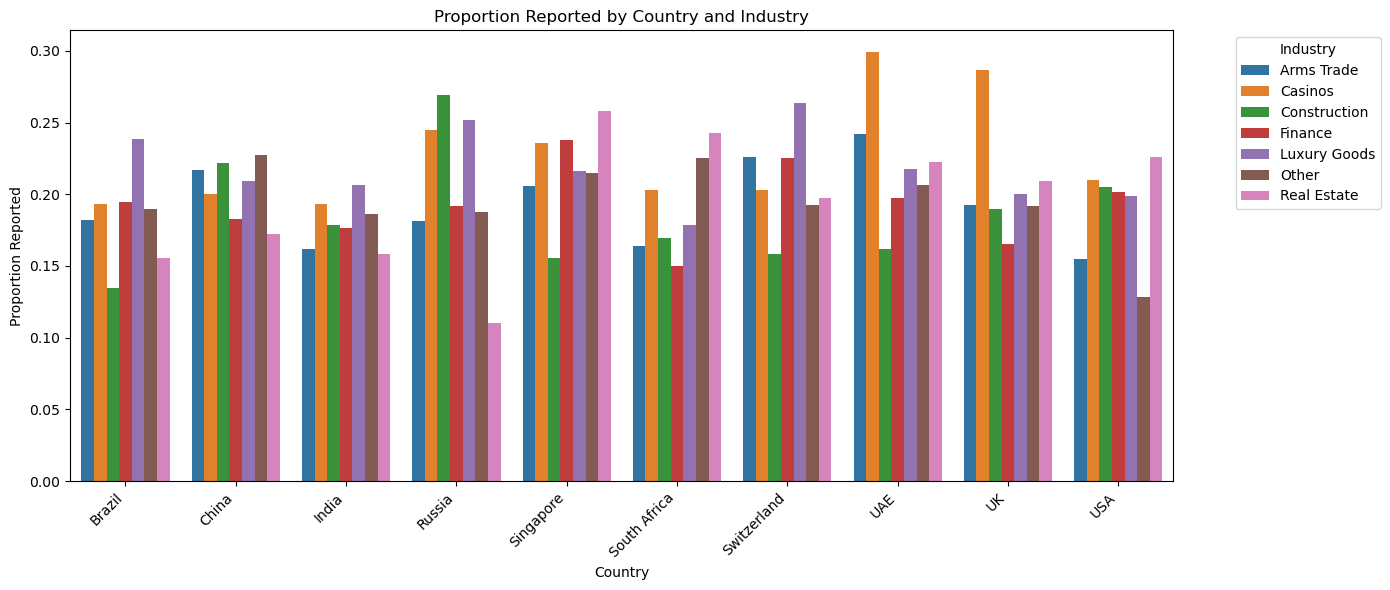

In [52]:
# computing reported proportion per (x,hue)
agg = df_plot.groupby([cat_x, cat_hue])[target].mean().reset_index(name='report_rate')

plt.figure(figsize=(14,6))
sns.barplot(data=agg, x=cat_x, y='report_rate', hue=cat_hue)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Proportion Reported')
plt.title(f'Proportion Reported by {cat_x} and {cat_hue}')
plt.legend(title=cat_hue, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The reporting pattern varies more clearly when **country** is examined with **industry**, suggesting that the interaction between these two features matters. Some of the highest proportions reported appear in **UAE-Casinos (about 30%)**, **UK-Casinos (about 28.6%)**, **Russia-Construction (about 26.9%)**, **Switzerland-Luxury Goods (about 26.4%)**, and **Singapore-Real Estate (about 25.8%)**. In contrast, some lower combinations include **Russia-Real Estate (about 11.0%)**, **USA-Other (about 13.0%)**, and **South Africa-Finance (about 15.0%)**. 


We tend to view how different Industry values compare within each Country.

**Multivariate logistic regression (joint effects)**

In [53]:
# Lets choose predictors (We can adjust where necessary)
predictors = ['Amount_USD', 'Country', 'Industry']  

In [54]:
# limit to top categories to keep model matrix reasonable
top_country = df_BBMoney_Data['Country'].value_counts().nlargest(10).index
top_ind = df_BBMoney_Data['Industry'].value_counts().nlargest(10).index
df_model = df_BBMoney_Data[df_BBMoney_Data['Country'].isin(top_country) & df_BBMoney_Data['Industry'].isin(top_ind)].copy()

In [55]:
# droping rows with missing target or predictors
df_model = df_model.dropna(subset=[target] + predictors)

In [56]:
# Lets encode categoricals with one-hot (drop_first avoids collinearity)
X = pd.get_dummies(df_model[predictors], drop_first=True)
y = df_model[target].astype(int)

In [57]:
# We can then add constant
X = sm.add_constant(X)

In [58]:
# Lets try fit logistic regression
logit = sm.Logit(y, X).fit(disp=False)
print(logit.summary())

                             Logit Regression Results                            
Dep. Variable:     Reported_by_Authority   No. Observations:                10000
Model:                             Logit   Df Residuals:                     9983
Method:                              MLE   Df Model:                           16
Date:                   Thu, 26 Mar 2026   Pseudo R-squ.:                0.002385
Time:                           18:23:51   Log-Likelihood:                -4999.0
converged:                          True   LL-Null:                       -5010.9
Covariance Type:               nonrobust   LLR p-value:                   0.09172
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.5639      0.111    -14.073      0.000      -1.782      -1.346
Amount_USD             9.591e-09   1.76e-08      0.546      0.585   -2.48e

The above **logistic regression** results indicate that **Amount, Country, and Industry** provide limited explanatory power for predicting whether a transaction is reported by authorities. The model has a very low Pseudo **R-squared (0.0024)** and is not statistically significant overall **(LLR p = 0.0917)**, suggesting weak predictive performance, which means the model as a whole is not statistically significant at the 5% level. Among the predictors, only **UAE and Casinos** show statistically significant positive effects, indicating slightly higher odds of reported cases relative to their reference categories.

### Correlation Analysis

**Correlation between the Target  and Feature Variables**

In [59]:
# Checking the correlation between features and the target.
cor = df_BBMoney_Data.corr()
cor

,Amount_USD,Reported_by_Authority,Money_Laundering_Risk_Score,Shell_Companies_Involved
Amount_USD,1.000000,0.005214,0.016529,-0.017905
Reported_by_Authority,0.005214,1.000000,0.003502,0.020544
Money_Laundering_Risk_Score,0.016529,0.003502,1.000000,-0.019262
Shell_Companies_Involved,-0.017905,0.020544,-0.019262,1.000000


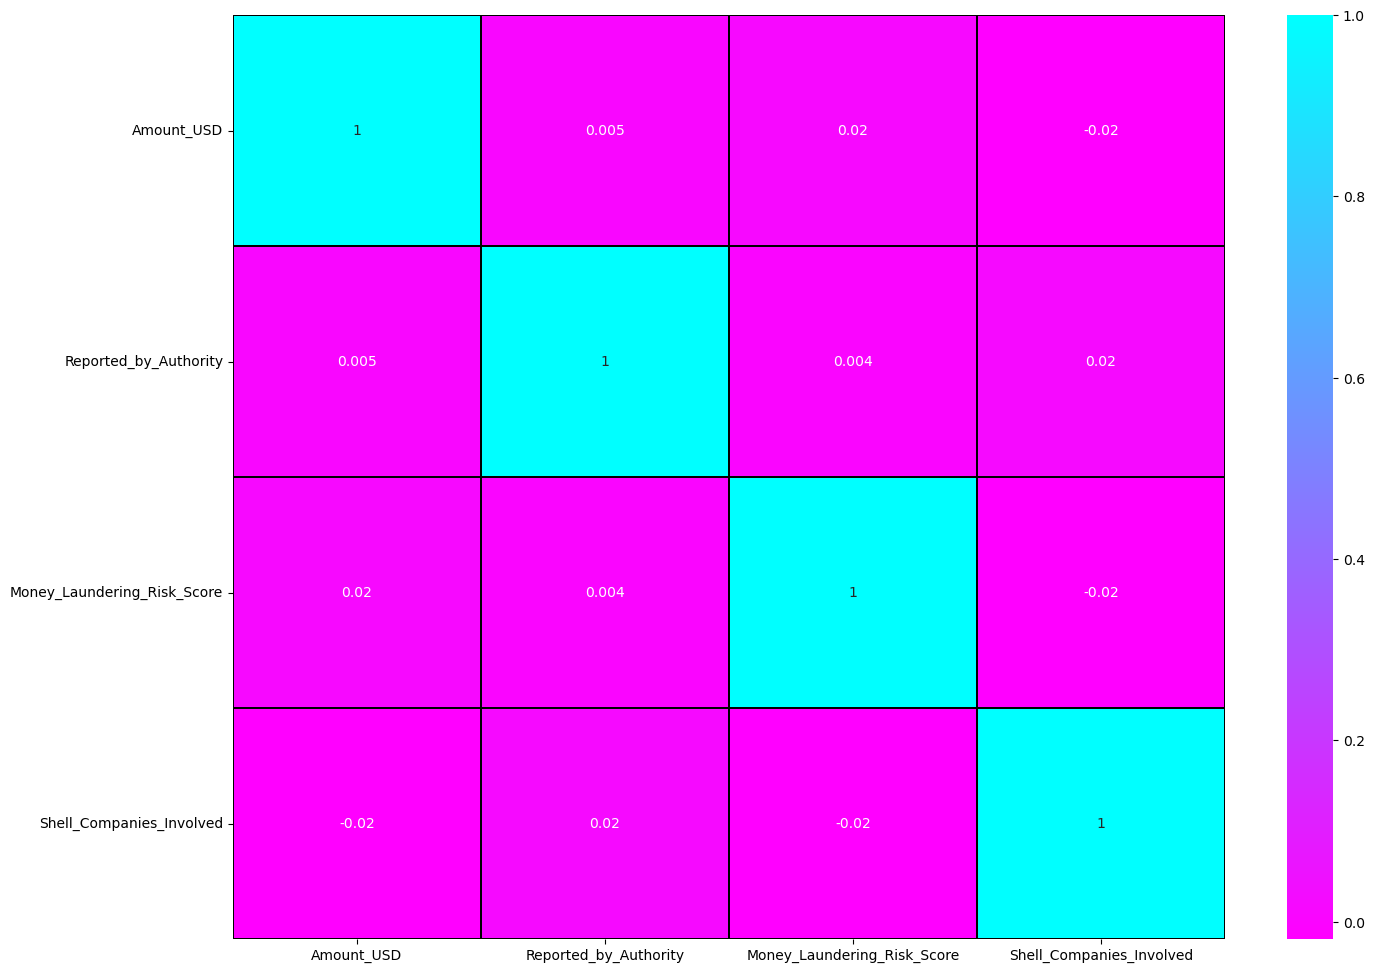

In [60]:
# Visualizing the correlation matrix by plotting heatmap
plt.figure(figsize = (16, 12))
sns.heatmap(df_BBMoney_Data.corr(), linewidths = 0.1, fmt = ".1g", linecolor = "black", annot = True, cmap = "cool_r")
plt.yticks(rotation = 0);
plt.show()

*  **0- no relation, -0.3 to +0.3- less correlation, greater than -0.5 or greater than +0.5- moderate correlation, greater than -0.7**

In [61]:
# Computing the correlation of all numeric columns with Target
df_BBMoney_Data.corr()['Reported_by_Authority'].sort_values(ascending = False)

Reported_by_Authority          1.000000
Shell_Companies_Involved       0.020544
Amount_USD                     0.005214
Money_Laundering_Risk_Score    0.003502
Name: Reported_by_Authority, dtype: float64

All the features have a positive relationship with the Target.

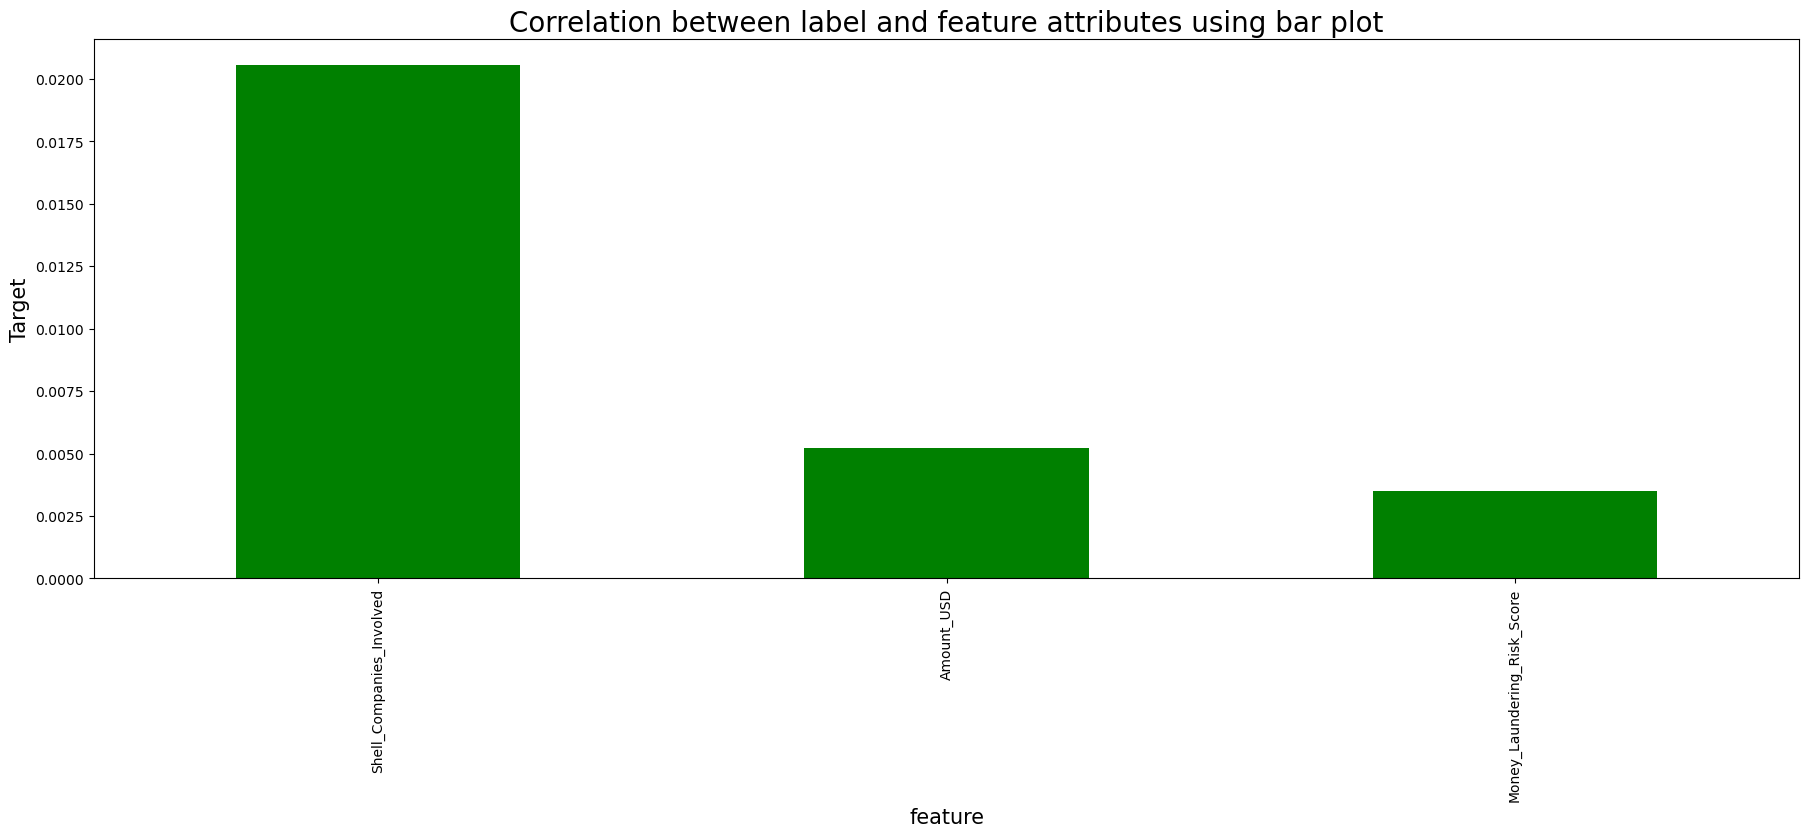

In [62]:
plt.figure(figsize = (22, 7))
df_BBMoney_Data.corr()['Reported_by_Authority'].sort_values(ascending = False).drop(['Reported_by_Authority']).plot(kind='bar',color="g")
plt.xlabel('feature', fontsize = 15)
plt.ylabel('Target', fontsize = 15)
plt.title("Correlation between label and feature attributes using bar plot", fontsize=20)
plt.show()

The above bar plot confirms that the numerical features have **very weak positive(+ve) correlations** with the target. **Shell_Companies_Involved** has the highest correlation at about **0.021**, followed by **Amount_USD** at about **0.005** and **Money_Laundering_Risk_Score** at about **0.004**. 


### Feature Engineering & Preprocessing

#### SPLITING THE VARIABLES INTO FEATURES(X) AND TARGET(Y)

In [63]:
# Identifying our independent variable (x) and dependant/target variable (y)
df_BBMoney_Data.columns = df.columns.str.strip().str.replace(' ', '_')
x = df_BBMoney_Data.drop("Transaction_ID", axis=1)
y = df_BBMoney_Data["Reported_by_Authority"]

**Feature Scaling using standard scalarization**

In [64]:
# Encode categorical columns
x_encoded = x.copy()
for col in x_encoded.select_dtypes(include=['object']).columns:
    x_encoded[col] = LabelEncoder().fit_transform(x_encoded[col])

In [65]:
# Scale the encoded data
scaler = StandardScaler()
x_scaled = pd.DataFrame(scaler.fit_transform(x_encoded), columns=x_encoded.columns)

x_scaled.head()

,Country,Amount_USD,Transaction_Type,Date_of_Transaction,Person_Involved,Industry,Destination_Country,Reported_by_Authority,Source_of_Money,Money_Laundering_Risk_Score,Shell_Companies_Involved,Financial_Institution,Tax_Haven_Country
0,-1.557707,0.537609,-0.008719,-1.731878,-1.695008,-0.506163,1.558846,1.996880,-0.652005,0.163680,-1.204808,0.595594,0.886797
1,-1.209461,1.729945,1.408991,-1.731531,0.772037,0.498527,0.166864,-0.500781,-0.652005,1.200501,-1.552075,1.069722,-1.475318
2,1.228266,-1.690418,1.408991,-1.731185,-0.714220,-0.506163,0.514859,1.996880,-0.652005,-1.564356,-0.510274,0.491007,1.477325
3,0.880019,-1.485226,-1.426428,-1.730838,-0.885269,1.000872,-0.529127,-0.500781,-0.652005,0.509287,-0.857541,0.233026,0.296268
4,0.183526,-1.304815,-0.717574,-1.730492,0.958436,1.503217,1.558846,1.996880,-0.652005,-1.564356,1.573328,1.418345,-0.294260


In [66]:
x_scaled.tail()

,Country,Amount_USD,Transaction_Type,Date_of_Transaction,Person_Involved,Industry,Destination_Country,Reported_by_Authority,Source_of_Money,Money_Laundering_Risk_Score,Shell_Companies_Involved,Financial_Institution,Tax_Haven_Country
9995,-0.164721,-0.205428,-0.008719,1.730492,0.553292,1.503217,-1.573114,-0.500781,-0.652005,-0.527535,-0.163007,-0.506055,-0.294260
9996,0.880019,1.613797,0.700136,1.730838,0.338934,0.498527,-0.529127,-0.500781,1.533731,1.546108,-0.857541,0.972108,-0.294260
9997,1.228266,-1.413068,1.408991,1.731185,-0.509730,1.000872,-0.529127,-0.500781,-0.652005,-0.181928,-1.552075,-1.293944,-0.884789
9998,-1.557707,-0.188330,-0.008719,1.731531,-1.044804,1.503217,-0.529127,1.996880,-0.652005,1.546108,0.184260,-1.572843,0.886797
9999,0.531773,-1.486450,1.408991,1.731878,-0.868274,-1.510853,-1.225118,1.996880,1.533731,-0.181928,-0.163007,-0.798899,0.296268


We have used the **Standard Scalarization method** to the data in order to mitigate potential biases and ensure **data integrity**.

**Checking Variance Inflation Factor(VIF)**

In [67]:
# Basic checks 
# Lets replace `X` below with your features DataFrame if X_enc is not already defined
try:
    X_check = X_enc.copy()
except NameError:
    try:
        X_check = X.copy()
        print("X_enc not found — using X instead.")
    except NameError:
        raise NameError("No X_enc or X found. Create a DataFrame of features first (e.g., X or X_enc).")

print("Shape (rows, cols):", X_check.shape)
print("Sample dtypes:\n", X_check.dtypes.head(20))

# Force numeric: encode categoricals and coerce non-numeric -> NaN 
# If X_check contains object columns, one-hot encode them (drop_first to reduce collinearity)
obj_cols = X_check.select_dtypes(include=['object','category']).columns.tolist()
if obj_cols:
    print("One-hot encoding object/category columns (this may expand columns):", obj_cols)
    X_check = pd.get_dummies(X_check, columns=obj_cols, drop_first=True)

# We Convert to numeric, coerce errors -> NaN
X_check = X_check.apply(pd.to_numeric, errors='coerce')

# Handling infinite and missing values
# Replace infs, then impute median
X_check = X_check.replace([np.inf, -np.inf], np.nan)
n_missing = X_check.isna().sum().sum()
print("Total missing values after coercion:", n_missing)

# If many NaNs, fill with median per column (safe for VIF)
X_check = X_check.fillna(X_check.median())

# Lets Drop constant columns (zero variance) 
const_cols = X_check.columns[X_check.nunique() <= 1].tolist()
if const_cols:
    print("Dropping constant columns:", const_cols)
    X_check = X_check.drop(columns=const_cols)

# Warn if too many features vs rows 
if X_check.shape[1] >= X_check.shape[0] / 2:
    print("Warning: many features relative to rows — VIF may be unstable or slow.")

# Computing VIF safely (skip problematic columns but report them) 
vif_results = []
skipped = []
for i, col in enumerate(X_check.columns):
    try:
        vif_val = variance_inflation_factor(X_check.values, i)
        vif_results.append((col, float(vif_val)))
    except Exception as e:
        skipped.append((col, str(e)))
        vif_results.append((col, np.nan))

vif_df = pd.DataFrame(vif_results, columns=['Feature','VIF']).sort_values('VIF', ascending=False).reset_index(drop=True)

# Showing Output 
print("\nTop VIFs:")
print(vif_df.head(15))

if skipped:
    print("\nColumns skipped or that raised errors during VIF computation:")
    for c, err in skipped:
        print(f" - {c}: {err}")

# We can then save vif_df for later inspection
# vif_df.to_csv('vif_results.csv', index=False)


X_enc not found — using X instead.
Shape (rows, cols): (10000, 17)
Sample dtypes:
 const                    float64
Amount_USD               float64
Country_China              uint8
Country_India              uint8
Country_Russia             uint8
Country_Singapore          uint8
Country_South Africa       uint8
Country_Switzerland        uint8
Country_UAE                uint8
Country_UK                 uint8
Country_USA                uint8
Industry_Casinos           uint8
Industry_Construction      uint8
Industry_Finance           uint8
Industry_Luxury Goods      uint8
Industry_Oil & Gas         uint8
Industry_Real Estate       uint8
dtype: object
Total missing values after coercion: 0
Dropping constant columns: ['const']

Top VIFs:
                  Feature       VIF
0              Amount_USD  3.398090
1        Industry_Finance  1.678478
2   Industry_Construction  1.670265
3   Industry_Luxury Goods  1.665938
4    Industry_Real Estate  1.658667
5      Industry_Oil & Gas  1.617506
6  

We looked at the Variance Inflation Factor (VIF) so it allows us to identify features that contribute to multicollinearity problems.Hence, the above analysis has revealed that non of the feature have a VIF value exceeding 10, meaning there are no strong correlation with other features.

In [68]:
# Target variable
df = df_BBMoney_Data.copy()
df['Reported_by_Authority'] = df['Reported_by_Authority'].astype(int)

In [69]:
# Drop IDs and non-informative columns
df = df_BBMoney_Data.drop(['Transaction_ID', 'Person_Involved', 'Date_of_Transaction'], axis=1)

In [70]:
# Split features and target
X = df_BBMoney_Data.drop('Reported_by_Authority', axis=1)
y = df_BBMoney_Data['Reported_by_Authority']

In [71]:
# Identify column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [72]:
# Preprocess
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
])

X_prep = preprocessor.fit_transform(X)

#### SPLITTING INTO TRAIN AND TEST USING THE 70:20 RULE

In [73]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X_prep, y, test_size=0.2, stratify=y, random_state=42)

### Balancing the Dataset With SMOTE

In [74]:
# Check class distribution before SMOTE
print("Before SMOTE:", Counter(y_train))

Before SMOTE: Counter({0: 6396, 1: 1604})


We have  observed that there is an imbalance in the dataset.The objective of this project involves classification and our intention is to rectify this imbalance using an oversampling technique known as the **SMOTE**.

In [75]:
# Applying SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [76]:
# Checking class distribution after SMOTE
print("After SMOTE:", Counter(y_train_res))

After SMOTE: Counter({0: 6396, 1: 6396})


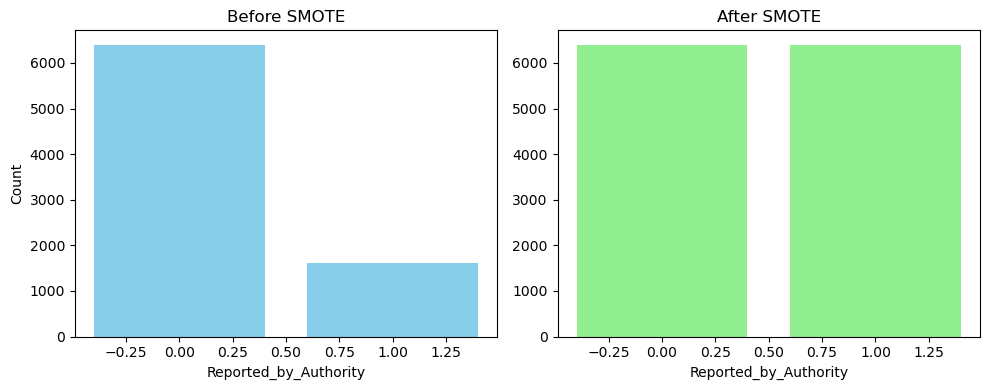

In [77]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(Counter(y_train).keys(), Counter(y_train).values(), color='skyblue')
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Reported_by_Authority")
axes[0].set_ylabel("Count")

axes[1].bar(Counter(y_train_res).keys(), Counter(y_train_res).values(), color='lightgreen')
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Reported_by_Authority")

plt.tight_layout()
plt.show()

The above charts shows that the dataset was **clearly imbalanced before SMOTE**, with the majority class having about **6,400 records** and the minority class about **1,600 records**. After applying **SMOTE**, both classes were balanced to approximately **6,400 records each**, indicating that the oversampling process successfully corrected the class imbalance before model training.

Lets building our **Machine learning (ML) classification models** since our data is now balanced .

### Machine Learning Models

**GENERATING THE ROC_AUC CURVE**

In [78]:
# Plotting the ROC_AUC curve
def plot_roc_auc(y_test, preds):
    '''
    Takes actual and predicted(probabilities) as input and plots the Receiver
    Operating Characteristic (ROC) curve
    '''
    fpr, tpr, threshold = roc_curve(y_test, preds)
    roc_auc = auc(fpr, tpr)
    plt.title('Receiver Operating Characteristic')
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

### Locating the best random state

In [79]:
# Base accuracy score should be better than always predicting the High-risk

# Baseline accuracy = proportion of the Reported_by_Authority 
counts = df_BBMoney_Data['Reported_by_Authority'].value_counts()
baseline_acc = counts.max() / counts.sum() * 100
print(f"Baseline accuracy to beat: {baseline_acc:.2f}%")

Baseline accuracy to beat: 79.95%


#### Traditional Machine Learning Models

**Logistic Regression**

In [80]:
# Checking accuracy for Logistic Regression
lor = LogisticRegression()

In [81]:
lor.fit(X_train, y_train)

LogisticRegression()

Classification Report (LR):
               precision    recall  f1-score   support

           0       0.80      1.00      0.89      1599
           1       0.00      0.00      0.00       401

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000

Confusion Matrix (LR):
 [[1599    0]
 [ 401    0]]


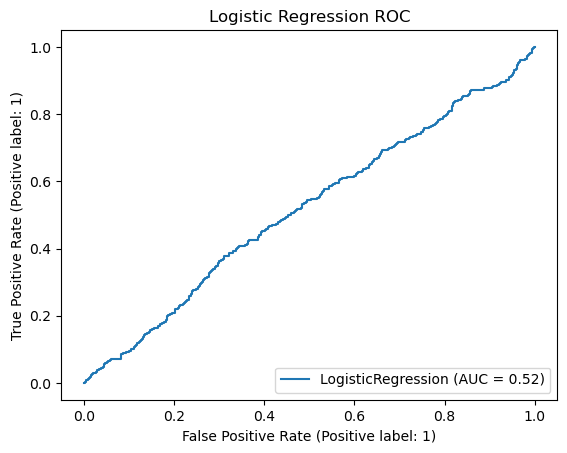

In [82]:
# y_test, X_test, lor must exist (lor is your trained LogisticRegression)
print("Classification Report (LR):\n", classification_report(y_test, lor.predict(X_test)))
print("Confusion Matrix (LR):\n", confusion_matrix(y_test, lor.predict(X_test)))

# ROC curve in one line
RocCurveDisplay.from_estimator(lor, X_test, y_test)
plt.title("Logistic Regression ROC")
plt.show()

The **Logistic Regression** model performed poorly, with an **AUC of 0.52**, which is only slightly better than random guessing. Although the model achieved **80% accuracy**, this is misleading because it predicted **only the majority class (0)** and failed to identify **any reported cases (class 1)**. The confusion matrix shows **1,599 true negatives** and **401 false negatives**, with **zero true positives(+ves)**, giving **0.00 precision, recall, and F1-score** for the positive class. This indicates that Logistic Regression was ineffective for detecting reported transactions in its current form.


### Random Forest Classifier

In [83]:
Ranfor = RandomForestClassifier()

In [84]:
Ranfor.fit(X_train, y_train)

RandomForestClassifier()

Classification Report (RF):
               precision    recall  f1-score   support

           0       0.80      1.00      0.89      1599
           1       0.00      0.00      0.00       401

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000

Confusion Matrix (RF):
 [[1599    0]
 [ 401    0]]


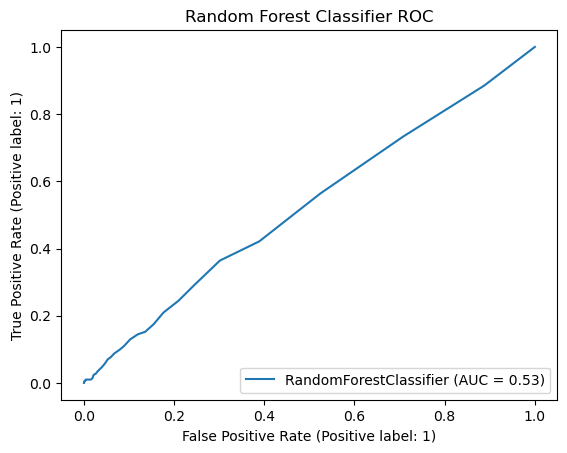

In [85]:
# y_test, X_test,while RandFor exists has our trained Random Forest Classifier
print("Classification Report (RF):\n", classification_report(y_test, Ranfor.predict(X_test)))
print("Confusion Matrix (RF):\n", confusion_matrix(y_test, Ranfor.predict(X_test)))

# ROC curve in one line
RocCurveDisplay.from_estimator(Ranfor, X_test, y_test)
plt.title("Random Forest Classifier ROC")
plt.show()

The **Random Forest** model also performed poorly, with an **AUC of 0.53**, indicating discrimination only slightly better than random chance. Like Logistic Regression, it achieved **80% accuracy** only because it predicted **every case as the majority class (0)**. The confusion matrix shows **1,599 true negatives** and **401 false negatives**, with **no true positives**, resulting in **0.00 precision, recall, and F1-score** for the positive class. This means the model failed completely to detect reported transactions and was not effective for the target class in this setup.


### XGBoost(Extreme Gradient Boosting) Classifier

In [86]:
XGBoost = XGBClassifier()

In [87]:
XGBoost.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)

Classification Report (XG):
               precision    recall  f1-score   support

           0       0.80      0.99      0.88      1599
           1       0.17      0.01      0.02       401

    accuracy                           0.79      2000
   macro avg       0.49      0.50      0.45      2000
weighted avg       0.67      0.79      0.71      2000

Confusion Matrix (XG):
 [[1580   19]
 [ 397    4]]


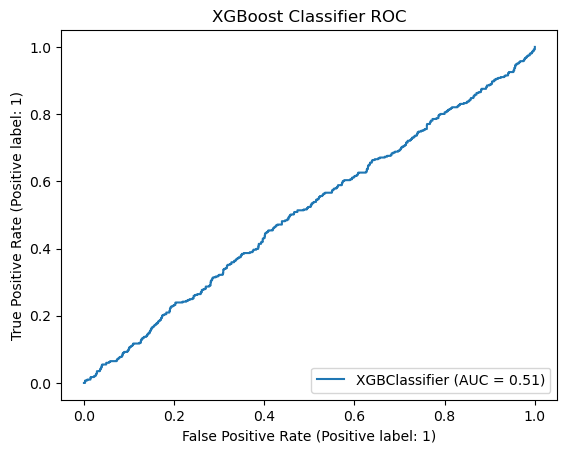

In [88]:
y_pred = XGBoost.predict(X_test)

# y_test, X_test, while the XGBoost is our trained XGBClassifier
print("Classification Report (XG):\n", classification_report(y_test, XGBoost.predict(X_test)))
print("Confusion Matrix (XG):\n", confusion_matrix(y_test, XGBoost.predict(X_test)))

# ROC curve in one line
RocCurveDisplay.from_estimator(XGBoost, X_test, y_test)
plt.title("XGBoost Classifier ROC")
plt.show()

The **XGBoost** model also performed poorly, with an **AUC of 0.51**, which is only marginally better than random guessing. It achieved **79% accuracy**, but this result is driven mainly by correct classification of the majority class. The model detected only **4 out of 401 reported cases**, while missing **397 positive cases**, resulting in a **recall of 0.01** and **F1-score of 0.02** for class 1. This indicates that XGBoost provided almost no practical improvement in identifying reported transactions.


### k-Nearest Neighbors (KNN)

In [89]:
# Creating a KNN Classifier
clf_knn = KNeighborsClassifier(n_neighbors=5)

In [90]:
clf_knn.fit(X_train, y_train)

KNeighborsClassifier()

Classification Report (KN):
               precision    recall  f1-score   support

           0       0.80      0.94      0.86      1599
           1       0.15      0.04      0.07       401

    accuracy                           0.76      2000
   macro avg       0.47      0.49      0.46      2000
weighted avg       0.67      0.76      0.70      2000

Confusion Matrix (KN):
 [[1497  102]
 [ 383   18]]


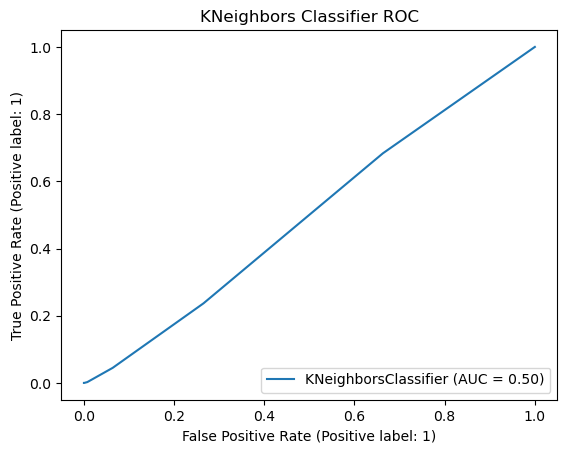

In [91]:
# y_test, X_test,while Knn exists has our trained Knn Classifier
print("Classification Report (KN):\n", classification_report(y_test, clf_knn.predict(X_test)))
print("Confusion Matrix (KN):\n", confusion_matrix(y_test, clf_knn.predict(X_test)))

# ROC curve in one line
RocCurveDisplay.from_estimator(clf_knn, X_test, y_test)
plt.title("KNeighbors Classifier ROC")
plt.show()

The **K-Nearest Neighbors (KNN)** model performed poorly, with an **AUC of 0.50**, indicating performance equivalent to random guessing. It achieved **76% accuracy**, but this was still driven mainly by the majority class. The model identified only **18 out of 401 reported cases**, while missing **383 positive cases**, which resulted in a **recall of 0.04** and **F1-score of 0.07** for class 1. This shows that KNN was not effective for detecting reported transactions in this dataset.


### Model Predictions

In [92]:
# Saving the model using .pkl
import joblib
joblib.dump(Ranfor, "Risk Identification & Fraud Detection In Related Party Transactions.pki")

['Risk Identification & Fraud Detection In Related Party Transactions.pki']

**Prediction On The Train Data**

In [93]:
modelname = RandomForestClassifier()

In [94]:
# Training the model on the training data
modelname.fit(X_train, y_train)

RandomForestClassifier()

In [95]:
# loading the saved model and get the predictions
Ranfor = joblib.load("Risk Identification & Fraud Detection In Related Party Transactions.pki")

# prediction
prediction = Ranfor.predict(X_train)
prediction

array([0, 0, 1, ..., 0, 0, 0])

In [96]:
a = np.array(y_train)
df_BBMoney_Data_train = pd.DataFrame()
df_BBMoney_Data_train["predicted"] = prediction
df_BBMoney_Data_train["original"] = a
df_BBMoney_Data_train

,predicted,original
0,0,0
1,0,0
2,1,1
3,1,1
4,0,0
...,...,...
7995,0,0
7996,0,0
7997,0,0
7998,0,0


**Prediction On The Test Data**

In [97]:
# Making predictions on the test data
predictions = Ranfor.predict(X_test)

In [98]:
# diagnostics
print("raw shapes:", np.shape(predictions), np.shape(y_test))

raw shapes: (2000,) (2000,)


In [99]:
# convert predictions -> 1D labels
pred_arr = np.asarray(predictions)
if pred_arr.ndim == 2:
    # if probabilities (two columns), take class with highest score
    if pred_arr.shape[1] == 1:
        pred_arr = pred_arr.ravel()
    else:
        # common case: class probs for binary -> take positive class
        # adjust as needed: use argmax for multiclass
        pred_arr = np.argmax(pred_arr, axis=1)

preds = pred_arr.ravel()

In [100]:
# convert y_test -> 1D
if isinstance(y_test, pd.DataFrame):
    y_true = y_test.squeeze().values
else:
    y_true = np.asarray(y_test).ravel()

In [101]:
# check shapes
if preds.shape[0] != y_true.shape[0]:
    raise ValueError(f"Length mismatch: preds={preds.shape[0]} vs y_true={y_true.shape[0]}")

In [102]:
# final DataFrame
conclusion = pd.DataFrame({'Predicted': preds, 'Original': y_true})
print(conclusion.shape)
conclusion.head()

(2000, 2)


,Predicted,Original
0,0,0
1,0,1
2,0,0
3,0,0
4,0,0


In [103]:
print(conclusion)

      Predicted  Original
0             0         0
1             0         1
2             0         0
3             0         0
4             0         0
...         ...       ...
1995          0         1
1996          0         1
1997          0         0
1998          0         0
1999          0         0

[2000 rows x 2 columns]


### The End